#BA 305 Project Notebook

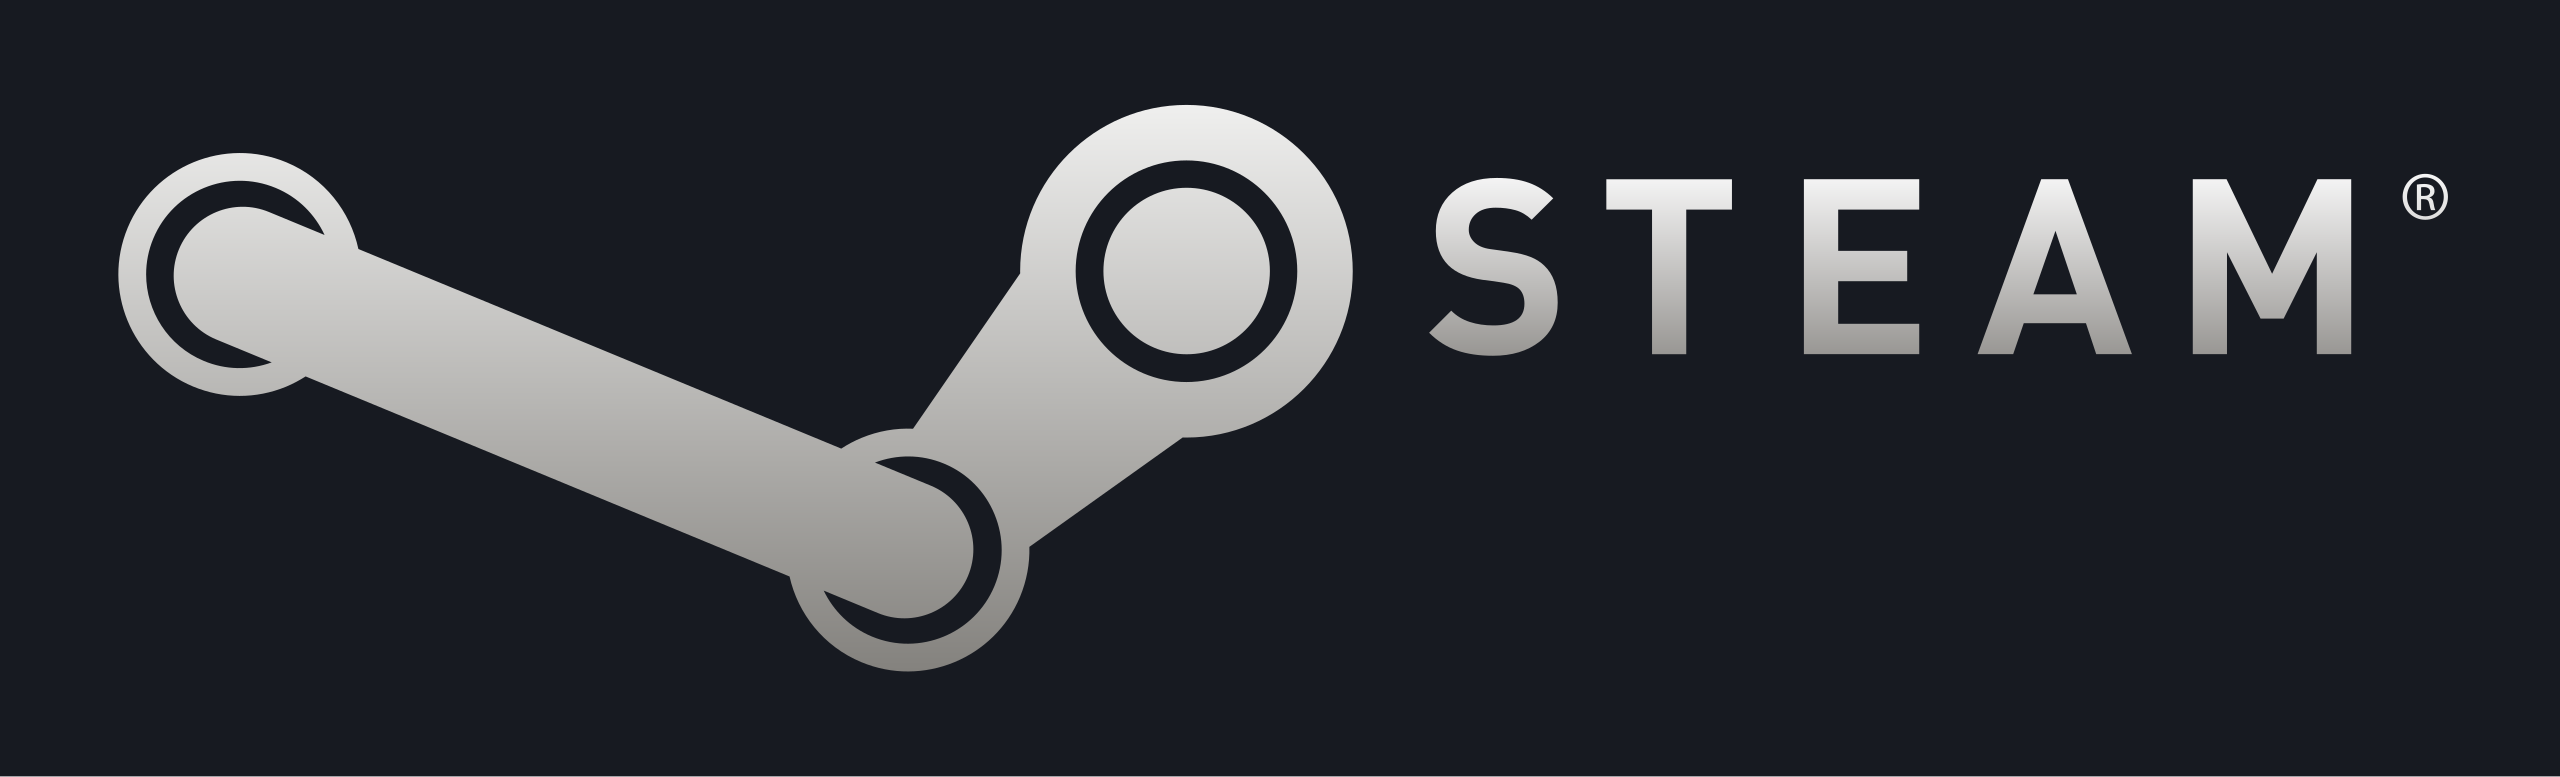

Welcome to our project notebook. For our dataset, we have worked on a steam games dataset. Each row represents a game with information about it that can be found on the game's page on steam.

##Background

* Steam is an online game distribution platform where video game developers submit their projects for players to enjoy.
* Developers are the people who create the game and control various aspects, such as graphics, controls, and gameplay.
* Publishers distribute the games and use their reputation to attract an established player base when a game comes out.   

##Problems to solve:

*   Developers want to make games that players actually enjoy.
*   Games take a long time to develop, so developers want to make sure the next game is a hit.
*   Publisher relationships depend on game's reception, potentially influencing the developers future revenues

##General Dataset Infromation##

* 39 columns including different facts about the game available in the Steam page of the game(such as number of positive reviews, metacrtiic score, etc.).
* 96509 unique games in the dataset.
* Data source: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset.  

##Information for each game



1.   AppID: the ID of the application in the steam dataset.
2.   Name: the name of the game.
3. Release date: the date at which the game was released.
4. Estimated Owners: the number of people who own the game(in ranges: 0-20000, 50000-100000, etc.)
5. Peak CCU: the highest number of users who play the game at the same time.
6. Required age: the age required to play the game.
7. Price: the price of the game in the US Steam store.
8. DLC count: the number of Downloadable Content(content released for a game after its initial release date).
9. About the game: a descriptoin of the game.
10. Supported Languages: the languages the game supports(in text).
11. Full audio languages: the audio languages the game supports.
12. Reviews: the number of reviews the game received.
13. Header image: the head image of the game when viewed in Steam.
14. Website: link to the official website of the game.
15. Support url: link to find support resources for the game.
16. Support email: an email to ask for support for a specific game.
17. Windows: whether the game is available on windows or not(1 if yes, and 0 if no).
18. Mac: whether the game is available on mac or not(1 if yes, and 0 if no).
19. Linux: whether the game is available in linux or not(1 if yes, and 0 if no).
20. Metacritic score: a score that represents the critical consensus for the game.
21. User score: the number of players who have purchased and reviewed the game and reccommended it.
22. Positive: the number of users who have given a positive review for the game.
23. Negative: the number of players who have given a negative review for the game.
24. Score rank: the ranking within a specific game or community activity.
25. Achievements: the number of achivements in the game.
26. Recommendations: the number of reccomendations given for the game.
27. Notes: warnings the game may have(such as for age restrictions or seizures).
28. Average playtime forever: the average plyatime the game has recieved since being released.
29. Average playtime two weeks: the average playtime the game has received over the last two weeks.
30. Median playtime forever: the median amount of playtime the game has recieved since being released.
31. Median playtime two weeks: the median amount of playtime the game has received over the last two weeks.
32. Developers: the developer who developed the game.
33. Publsihers: the publisher who published the game.
34. Categories: the categories the game is a part of on the steam page.
35. Genres: the genres the game has on its steam page.
36. Tags: the tags that the game has on its steam page.
37. Screenshots: the screenshots taken by the players of the game.
38. Movies: trailers or other promotional material for the game shown on the steam page for the game.




##Project Objective

Develop a model that is able to predict how positively players would review the game based on the game's features.

##Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import *
%matplotlib inline
import matplotlib.pylab as plt
from sklearn import preprocessing
from sklearn.tree import DecisionTreeRegressor
import seaborn as sns
import math
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor


# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Data Pre-Processing**

When defining the dataset into a data frame some of the columns were misplaced, so we resolved the issue with the code below.

In [ ]:
#Define the dataframe
df = pd.read_csv('/content/drive/MyDrive/games.csv')
df.head()

#Rename the columns for data consistencty
steam_df = df.rename(columns = {'AppID' : 'Name', 'Name' : 'Release date', 'Release date' : 'Estimated owners',
'Estimated owners' : 'Peak CCU', 'Peak CCU' : 'Required age', 'Required age' : 'Price', 'Price' : 'Discount',
'DiscountDLC count' : 'DLC count'})


#Remove rows where both positive and negative columns are neagtive
steam_df = steam_df[~((steam_df['Positive'] == 0) & (steam_df['Negative'] == 0))]

#Force pandas to display all the columns
pd.set_option('display.max_columns', None)

#Show the head of the dataset
steam_df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
20200,Galactic Bowling,"Oct 21, 2008",0 - 20000,0,0,19.99,0,0,Galactic Bowling is an exaggerated and stylize...,['English'],[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://www.galacticbowling.net,NaN,NaN,True,False,False,0,NaN,0,6,11,NaN,30,0,NaN,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
655370,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://trainbandit.com,NaN,support@rustymoyher.com,True,True,False,0,NaN,0,53,5,NaN,12,0,NaN,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1355720,Henosis™,"Jul 23, 2020",0 - 20000,0,0,5.99,0,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,https://henosisgame.com/,https://henosisgame.com/,info@henosisgame.com,True,True,True,0,NaN,0,3,0,NaN,0,0,NaN,0,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1139950,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0,0,0.00,0,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,https://www.unusual-games.com/home/,https://www.unusual-games.com/contact/,welistentoyou@unusual-games.com,True,True,False,0,NaN,0,50,8,NaN,17,0,This Game may contain content not appropriate ...,0,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1469160,Wartune Reborn,"Feb 26, 2021",50000 - 100000,68,0,0.00,0,0,Feel tired of auto-fight? Feel tired of boring...,['English'],[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,NaN,https://7.wan.com,https://wartune@7road.com,True,False,False,0,NaN,0,87,49,NaN,0,0,NaN,0,0,0,0,7Road,7Road,"Single-player,Multi-player,MMO,PvP,Online PvP,...","Adventure,Casual,Free to Play,Massively Multip...","Turn-Based Combat,Massively Multiplayer,Multip...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


We created a correlation matrix to make sure we did not have a problem of multicollinerity between our predictors

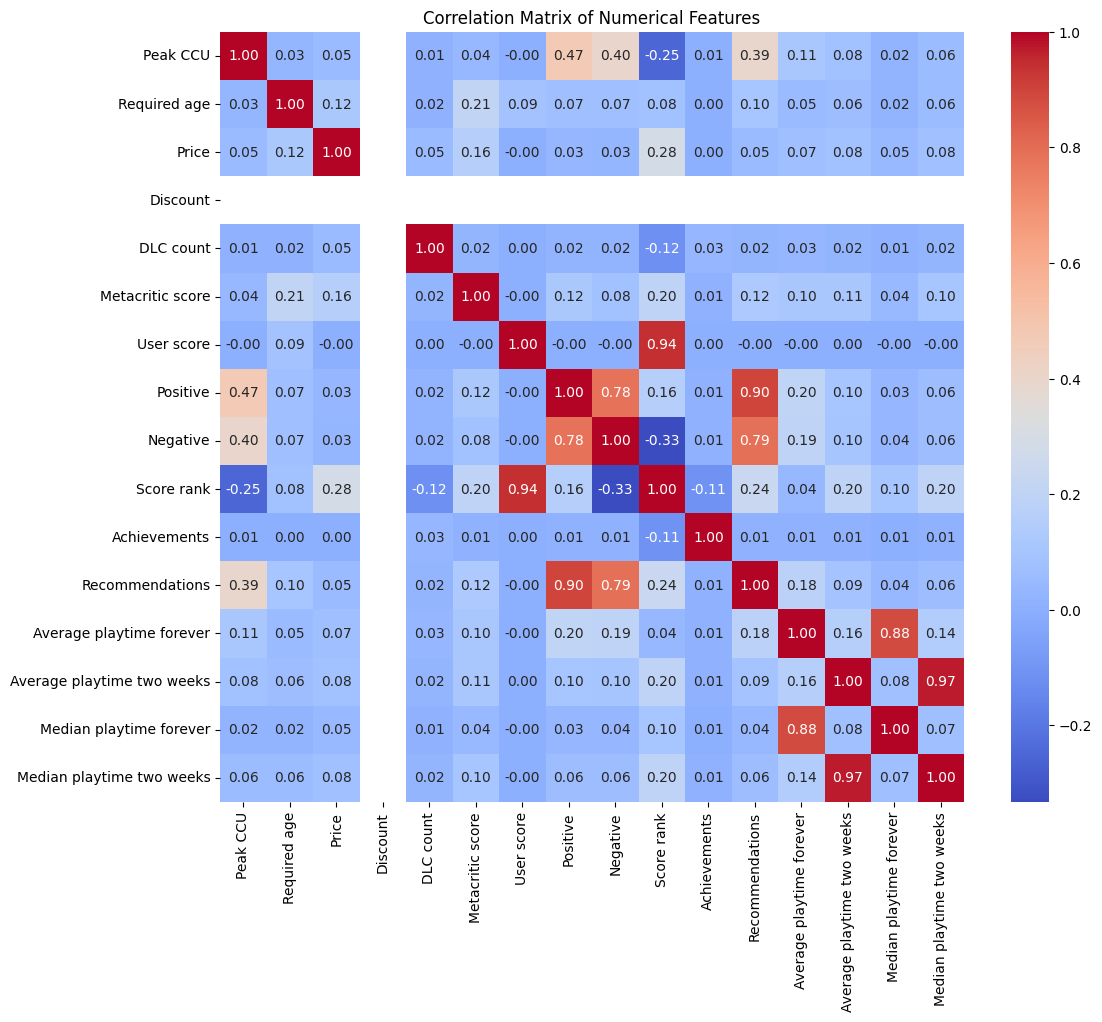

In [ ]:
# Defining seperate lists for numerical and categorical columns of steam_df
numerical_cols = steam_df.select_dtypes(include=['number']).columns
categorical_cols = steam_df.select_dtypes(exclude=['number']).columns

# Drop categorical columns
steam_df_numerical = steam_df.drop(columns=categorical_cols)

# Calculate correlation matrix
correlation_matrix = steam_df_numerical.corr()


# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## **Data Cleaning**

This is our 4th iteration of Data cleaning for this dataset. In this iteraiton, we tried mergin our steam_df with other steam dataframes to see if we could get better prediction accuracies with new features.

###Merging Datasets for new columns###

####Extra columns from previous iteration

In the previous iteration, notes quality scores and About the game writing quality had fairly high feature importance for Random forests, so we decided to keep them in this iteration. However, we removed most of the other ChatGPT generated columns because they were not providing substnatial decreases in RMSE and their feature importances were low.

In [ ]:
#Merging the Notes quality
notes_with_quality_scores=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/notes_with_quality_scores.csv')
notes_with_quality_scores.rename(columns={'Unique Notes': 'Notes'}, inplace=True)
import pandas as pd
# Merge the two dataframes based on the 'About the game' column
steam_df = pd.merge(steam_df, notes_with_quality_scores, on='Notes', how='left')



#Merging the About the game writing quality
About_game_ratings=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/about_the_game_with_ratings.csv')
import pandas as pd
# Merge the two dataframes based on the 'About the game' column
steam_df = pd.merge(steam_df, About_game_ratings, on='About the game', how='inner')


####Extra Dataset 1##

This is the first dataset about steam which we tried to join with our own. This new dataset included a column called player behavior, which we thought could be important for our predictor. However, when merging this dataset with our own we have ran into a problem where the game names would repeate twice. This first extra dataset includes the names of one game multiple times, making it hard for us to prorperly merge this one with our own.We have tried to group the values by name but after doing so the dataset was only left with around 5000 rows, making it not worthwhile to merge with this one. As a result, we just ignored it and tried the other datasets.  Dataset Link: https://www.kaggle.com/datasets/tamber/steam-video-games  

In [ ]:
#Adding the first Extra Dataset
steam_extra_1=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/steam-200k.csv')


# Rename columns in steam_extra_1 DataFrame
steam_extra_1 = steam_extra_1.rename(columns={'1.0': 'hours of play', 'The Elder Scrolls V Skyrim': 'Name', 'purchase': 'behavior'})

#Dropping the columns we would not need
steam_extra_1=steam_extra_1.drop(['151603712','0'], axis=1)

#Printing the shape of the dataset
print(steam_extra_1.shape)

#Dropping Null values
steam_extra_1=steam_extra_1.dropna()

#Showing the head of the dataset
steam_extra_1.head()

(199999, 3)


,Name,behavior,hours of play
0,The Elder Scrolls V Skyrim,play,273.0
1,Fallout 4,purchase,1.0
2,Fallout 4,play,87.0
3,Spore,purchase,1.0
4,Spore,play,14.9


In [ ]:
#Grouping the observations by game name but found there are too few columns to merge with our dataset
steam_extra_1_grouped = steam_extra_1.groupby('Name').agg(
    {'behavior': list, 'hours of play': 'max'}
)

steam_extra_1_grouped


,behavior,hours of play
Name,,
007 Legends,"[purchase, play]",1.0
0RBITALIS,"[purchase, play, purchase, play, purchase, play]",1.0
1... 2... 3... KICK IT! (Drop That Beat Like an Ugly Baby),"[purchase, play, purchase, play, purchase, pla...",11.2
10 Second Ninja,"[purchase, purchase, purchase, play, purchase,...",5.4
"10,000,000","[purchase, play]",3.6
...,...,...
sZone-Online,"[purchase, play, purchase, play, purchase, pur...",6.7
samurai_jazz,[purchase],1.0
the static speaks my name,"[purchase, play, purchase, play, purchase, pla...",1.0


####Extra Dataset 2##

This is the second extra dataset we have decided to potentially merge with our own. The problem with this one was that the game names with this dataset seemingly do not overlap with our own because after merging this dataset with copy_df(a copy of steam_df dataset) we would 0 rows leftover. As a result, we have decided to leave this dataset and try the next extra dataset. The columns we were interested from this extra dataset wre Average Hours Played Since 2009, and Median Hours Played Since 2009. Dataset link:https://www.kaggle.com/datasets/eringray/steam-games-dataset  

In [ ]:
#Adding the second extra Dataset
steam_extra_2=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/Steam_Games_Dataset.csv')

#Drop the columns we are not interested in
steam_extra_2=steam_extra_2.drop(['Metascore','Price','Release_date','Publishers'],axis=1)

#Drop the null values in the extra dataset
steam_extra_2=steam_extra_2.dropna()

#Rename the game column in the second extra dataset to name so that we can merge with our dataset easier
steam_extra_2=steam_extra_2.rename(columns={'Game':'Name'})

#Print the shape of the dataset
print(steam_extra_2.shape)

#Show the head of the second extra dataset
steam_extra_2.head()

(53090, 5)


,Game_Type,Name,Owners,Average_Hours-Played_Since_2009,Median_Hours_Played_Since_2009
0,Strategy,Counter-Strike: Global Offensive,"200,000,000",26,16
1,Action,Dota 2,"200,000,000",26,16
2,RPG,Team Fortress 2,"100,000,000",33,25
3,Adventure,ARK: Survival Evolved,"100,000,000",33,25
4,Action,PUBG: BATTLEGROUNDS,"100,000,000",33,25


In [ ]:
#Create a copy of steam_df dataset
copy_df=steam_df.copy()

# Merge copy_df and steam_extra_2 based on the 'Name' column
copy_df = pd.merge(copy_df, steam_extra_2, on='Name', how='left')

#Drop the null values in the merged dataset
copy_df=copy_df.dropna()

#Print the shape of the new dataset
print(copy_df.shape)

(0, 45)


####Extra Dataset 3##

This is our 3rd extra dataset and we did ultimately merge it with our own. This columns we wanted from this dataset were pictures posted recently(pcs_pos_recent), total pictures posted(pct_pos_total), num_reviews_total, num_reviews_recent, short_description, and detailed_description. For the short_description and detailed_description columns, we did a similar transformation appraoch as the about the game column, where we extracted the unique values and gave it to ChatGPT so that it could give us quality ratings and we imported those values into our dataset. Dataset link: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset  

In [ ]:
#Adding the third extra dataste
steam_extra_3=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/games_march2025_cleaned.csv')

#Printing the columns in the 3rd extra dataset
print(steam_extra_3.columns)


#Dropping the columns we would need
steam_extra_3=steam_extra_3.drop(['appid','release_date','required_age','dlc_count','price','reviews','header_image','website','support_url','support_email','windows','mac','linux','metacritic_score','metacritic_url','achievements','recommendations','notes','supported_languages','full_audio_languages','packages', 'developers', 'publishers',
       'categories', 'genres', 'screenshots', 'movies', 'user_score',
       'score_rank', 'positive', 'negative', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks', 'discount',
       'peak_ccu', 'tags'], axis=1)

#Dropping the null values in the dataset
steam_extra_3=steam_extra_3.dropna()

#Printing the shape of the dataset
print(steam_extra_3.shape)

#Rename the name column to Name so that we could merge it with our own dataset
steam_extra_3 = steam_extra_3.rename(columns={'name': 'Name'})

#Show the head of the dataset.
steam_extra_3.head()

Index(['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count',
       'detailed_description', 'about_the_game', 'short_description',
       'reviews', 'header_image', 'website', 'support_url', 'support_email',
       'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url',
       'achievements', 'recommendations', 'notes', 'supported_languages',
       'full_audio_languages', 'packages', 'developers', 'publishers',
       'categories', 'genres', 'screenshots', 'movies', 'user_score',
       'score_rank', 'positive', 'negative', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks', 'discount',
       'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total',
       'pct_pos_recent', 'num_reviews_recent'],
      dtype='object')
(89396, 8)


,Name,detailed_description,about_the_game,short_description,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,Counter-Strike 2,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",86,8632939,82,96473
1,PUBG: BATTLEGROUNDS,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,59,2513842,68,16720
2,Dota 2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",81,2452595,80,29366
3,Grand Theft Auto V Legacy,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,87,1803832,92,17517
4,Tom Clancy's Rainbow Six® Siege,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",84,1168020,76,12608


In [ ]:
#Redefine copy_df
copy_df=steam_df.copy()

# Merge copy_df and steam_extra_3 based on the 'Name' column
copy_df = pd.merge(copy_df, steam_extra_3, on='Name', how='left')

#Print the shape of copy_df
print(copy_df.shape)

# Display the merged DataFrame
print(copy_df.head())

#Make Steam_df the same as copy_df
steam_df=copy_df.copy()

(78457, 48)
                    Name  Release date Estimated owners  Peak CCU  \
0       Galactic Bowling  Oct 21, 2008        0 - 20000         0   
1           Train Bandit  Oct 12, 2017        0 - 20000         0   
2               Henosis™  Jul 23, 2020        0 - 20000         0   
3  Two Weeks in Painland   Feb 3, 2020        0 - 20000         0   
4         Wartune Reborn  Feb 26, 2021   50000 - 100000        68   

   Required age  Price  Discount  DLC count  \
0             0  19.99         0          0   
1             0   0.99         0          0   
2             0   5.99         0          0   
3             0   0.00         0          0   
4             0   0.00         0          0   

                                      About the game  \
0  Galactic Bowling is an exaggerated and stylize...   
1  THE LAW!! Looks to be a showdown atop a train....   
2  HENOSIS™ is a mysterious 2D Platform Puzzler w...   
3  ABOUT THE GAME Play as a hacker who has arrang...   
4  Feel ti

In [ ]:
# Export the unique values of detailed and short description as CSVs

import pandas as pd
# Extract unique values from 'detailed_description' and 'short_description'
unique_detailed_descriptions = steam_df['detailed_description'].unique()
unique_short_descriptions = steam_df['short_description'].unique()

# Create DataFrames for each
detailed_desc_df = pd.DataFrame({'detailed_description': unique_detailed_descriptions})
short_desc_df = pd.DataFrame({'short_description': unique_short_descriptions})

# Save to CSV files
detailed_desc_df.to_csv('unique_detailed_descriptions.csv', index=False)
short_desc_df.to_csv('unique_short_descriptions.csv', index=False)


In [ ]:
#Read the csv files with the description ratings as Dataframes
detailed_descriopntion_ratings=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/detailed_descriptions_with_float_ratings.csv')
short_descriptions_with_ratings=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/short_descriptions_with_ratings.csv')


# Merge steam_df and detailed_descriopntion_ratings based on 'detailed_description'
steam_df = pd.merge(steam_df, detailed_descriopntion_ratings, on='detailed_description', how='left')

# Merge steam_df and detailed_descriopntion_ratings based on 'detailed_description'
steam_df = pd.merge(steam_df, short_descriptions_with_ratings, on='short_description', how='left')


steam_df=steam_df.drop(['detailed_description','about_the_game','short_description'],axis=1)

###Removing Unnecessary columns and null values

When looking through our dataset, we had a few columns that we would not be able to use, such as Support Url and Screenshots, or columns with a lot of null values so we decided to drop them. Furthermore, we decided to drop all null values for now and then come back to them later.

In [ ]:
#Defining the list of columns to drop
col_to_be_dropped= ['Reviews','Website','Support url','Support email','Metacritic url','Header image','Score rank','Screenshots','Movies','Notes']

#Drop the unnecessary columns
steam_df=steam_df.drop(col_to_be_dropped,axis=1)

#Dropping the null values from the dataset
steam_df=steam_df.dropna()

#Showing the shape of our dataset
print(steam_df.shape)

#Checking if columns still have null values
steam_df.isnull().sum()

(59425, 37)


,0
Name,0
Release date,0
Estimated owners,0
Peak CCU,0
Required age,0
Price,0
Discount,0
DLC count,0
About the game,0
Supported languages,0


###Data Transformations###

Our dataset had a lot of categorical columns which would not go well with the models we covered in class. So we decided to transform the columns in the code below

####Redefining Columns####

We created our response variable column Positive% and dropped the Positive and Negative columns since they would be highly correlated with the response variable.

In [ ]:
steam_df['Positive%'] = steam_df['Positive'] / (steam_df['Positive'] + steam_df['Negative']) * 100
steam_df=steam_df.drop(['Positive','Negative'],axis=1)
steam_df.head()

<ipython-input-49-04685b583163>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  steam_df['Positive%'] = steam_df['Positive'] / (steam_df['Positive'] + steam_df['Negative']) * 100


,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Windows,Mac,Linux,Metacritic score,User score,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Note Quality (0–10),Writing Quality Rating,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,Detailed Description Rating (0–10),Short Description Rating (0–10),Positive%
1,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,True,False,0,0,12,0,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",0,8.8,86.0,68.0,-1.0,-1.0,9.23,9.40,91.379310
2,Henosis™,"Jul 23, 2020",0 - 20000,0,0,5.99,0,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,True,True,0,0,0,0,0,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",0,9.4,-1.0,-1.0,-1.0,-1.0,9.80,8.10,100.000000
3,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0,0,0.00,0,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",[],True,True,False,0,0,17,0,0,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",6,9.0,89.0,65.0,-1.0,-1.0,9.30,9.00,86.206897
4,Wartune Reborn,"Feb 26, 2021",50000 - 100000,68,0,0.00,0,0,Feel tired of auto-fight? Feel tired of boring...,['English'],[],True,False,False,0,0,0,0,0,0,0,0,7Road,7Road,"Single-player,Multi-player,MMO,PvP,Online PvP,...","Adventure,Casual,Free to Play,Massively Multip...","Turn-Based Combat,Massively Multiplayer,Multip...",0,9.2,63.0,257.0,-1.0,-1.0,7.93,8.76,63.970588
5,TD Worlds,"Jan 9, 2022",0 - 20000,3,0,10.99,0,1,"TD Worlds is a dynamic, highly strategical gam...","['English', 'Russian', 'Danish']",[],True,False,False,0,0,62,0,0,0,0,0,MAKSIM VOLKAU,MAKSIM VOLKAU,"Single-player,Steam Achievements,Steam Cloud","Indie,Strategy","Tower Defense,Rogue-lite,RTS,Replay Value,Perm...",0,9.1,69.0,26.0,-1.0,-1.0,9.31,8.58,75.000000


For publishers and developers columns we had too many unique values. We decided to create aggregate grouping based on how many games the publishers and developers made. The reasoning is that with more games made, the publishers and developers would have more experience which would translate into a theoretically better game.

In [ ]:
# prompt: Create a new column called "Num games published by publisher" that counts the number of games each publisher has published

import pandas as pd
# Group by publisher and count the number of games
publisher_game_counts = steam_df.groupby('Publishers')['Name'].count().reset_index()
publisher_game_counts.rename(columns={'Name': 'Num games published by publisher'}, inplace=True)

# Merge the counts back into the original DataFrame
steam_df = pd.merge(steam_df, publisher_game_counts, on='Publishers', how='left')




# Group by publisher and count the number of games
publisher_game_counts = steam_df.groupby('Developers')['Name'].count().reset_index()
publisher_game_counts.rename(columns={'Name': 'Num games developed by developer'}, inplace=True)

# Merge the counts back into the original DataFrame
steam_df = pd.merge(steam_df, publisher_game_counts, on='Developers', how='left')

We also exttracted the Release month from the Release date column because we thouhgt the month a game released can have an impact towards its positive%. We then grouped into an aggregate category based on the month's season. We did this so that our models would not think 12(December) is more than (2) February and etc.

In [ ]:
# Assuming 'Release date' column contains date strings
steam_df['Release Month'] = pd.to_datetime(steam_df['Release date'], errors='coerce', format='mixed').dt.month

# Create a function to categorize release months into seasons
def categorize_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Unknown'  # Handle potential invalid month values

# Apply the function to create a new 'Season' column
steam_df['Season'] = steam_df['Release Month'].apply(categorize_season)

We have also extracted the Release Year column to see if how old a game is has an impact on the Positive%

In [ ]:
#Extract the Year of release for the games from the Release date column
steam_df['Release Year'] = pd.to_datetime(steam_df['Release date'], errors='coerce', format='mixed').dt.year

# Calculate the 'Years old' column
steam_df['Years old'] = 2025 - steam_df['Release Year']

# Drop the original 'Release date' column
steam_df = steam_df.drop(['Release date', 'Release Year'], axis=1)

We created new columns for Categories, Genres and Tags that count how many of each category are present for the game.

In [ ]:
# prompt: Can you create new columns from Categories, Genres, and Tags that are called "Number of" column name which each represent the number of instances in their respective columns

# Assuming 'steam_df' is your DataFrame as defined in the provided code.

# Function to process categorical columns and create 'Number of' columns
def process_categorical_column(df, column_name):
    """
    Creates a new column representing the count of elements in a categorical column.

    Args:
        df: The DataFrame.
        column_name: The name of the categorical column.
    """
    new_column_name = f"Number of {column_name.replace('_', ' ').title()}"
    df[new_column_name] = df[column_name].str.split(',').str.len()
    return df


# Apply the function to the specified columns
steam_df = process_categorical_column(steam_df, 'Categories')
steam_df = process_categorical_column(steam_df, 'Genres')
steam_df = process_categorical_column(steam_df, 'Tags')



Finally, we have created new columns for the languages columns based on the number of each supported and audio language.

In [ ]:
# prompt: For each game(row) can you count the number languages present for the game and create a new column called "Number of Supported Languages". Do the same for the audio languages, and create new column for it called "Number of audio languages"

# Count the number of languages and create new columns
steam_df['Number of Supported Languages'] = steam_df['Supported languages'].apply(len)
steam_df['Number of Audio Languages'] = steam_df['Full audio languages'].apply(len)


Finally, we created a predictor column positive% based on the number of positive reviews over the number of total reviews(positive+negative).

####Creating Dummy columns####

In this iteration, we only had 2 columns which needed dummy variables.

In [ ]:
# Create dummy variables for the 'Estimated owners' column
estimated_owners_dummies = pd.get_dummies(steam_df['Estimated owners'], prefix='Estimated_owners')

# Concatenate the dummy variables with the original DataFrame
steam_df = pd.concat([steam_df, estimated_owners_dummies], axis=1)

# Remove the original 'Estimated owners' column
steam_df = steam_df.drop('Estimated owners', axis=1)

In [ ]:
# Create dummy variables for 'Season'
season_dummies = pd.get_dummies(steam_df['Season'], prefix='Season')
steam_df = pd.concat([steam_df, season_dummies], axis=1)
steam_df = steam_df.drop('Season', axis=1)

####Dropping Columns

After all of the data transformations, we dropped all of the columns we no longer needed.

In [ ]:
steam_df=steam_df.drop(['Name','Supported languages','Full audio languages','Categories','Genres','Tags',
                        'Developers','Publishers','About the game','Release Month'],axis=1)

##Data Summary and Visualizations

After completing our Data cleaning at least for the presentation, we have decided to visualize our data just to identify any patterns in our dataset.

We wanted to check the relationship between pct_pos_total and Positive% because pct_pos_total was identified as the most important predictor. Judging from the graph, there is a positive realtionship between the two, but there are also some randomness with some observations not showing any relationship at all.

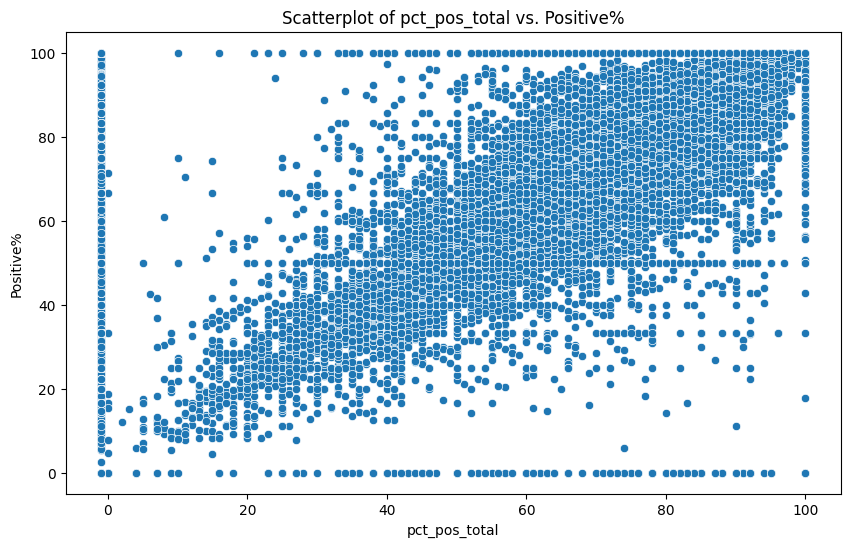

In [ ]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='pct_pos_total', y='Positive%', data=steam_df)
plt.title('Scatterplot of pct_pos_total vs. Positive%')
plt.xlabel('pct_pos_total')
plt.ylabel('Positive%')
plt.show()


We also wanted to check if the season when the game released had any impact, but after checking the box plots of positive% based on the season, there does not seem to be any strong relationship.

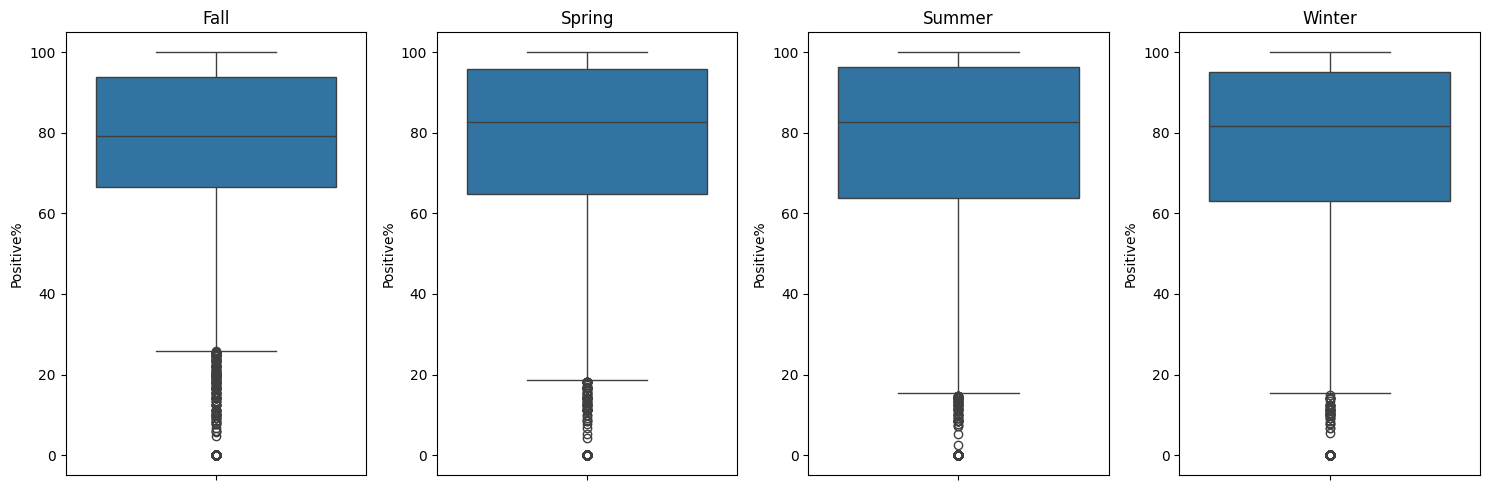

In [ ]:
seasons = ['Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter']
plt.figure(figsize=(15, 5)) # Adjust figure size for better side-by-side display

for i, season in enumerate(seasons):
  plt.subplot(1, 4, i + 1)  # Create subplots for each season
  sns.boxplot(y=steam_df[steam_df[season] == 1]['Positive%'])
  plt.title(season.replace('Season_', ''))
plt.tight_layout() # Adjust spacing between subplots
plt.show()

We also created a scatterplot of how old the game is vs. the Positive%. 15 or less year old games, seemingly do not have any strong correlation, but games older than 15 years are generally more positively received.

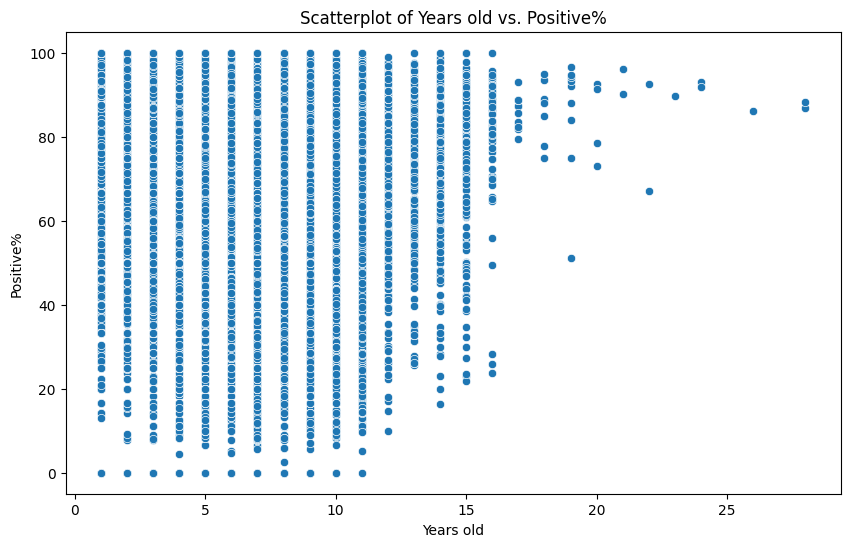

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Years old', y='Positive%', data=steam_df)
plt.title('Scatterplot of Years old vs. Positive%')
plt.xlabel('Years old')
plt.ylabel('Positive%')
plt.show()

Next, we wanted to check how the description and note rating columns created Chatgpt related to our response variable. Looking at the graph, a lot of the number generated by Chatgpt were more concentrated on the higher spectrum of the rating(a lot of 8,9,10), with some being on the left side of the graph.Furthermore, it does not seem like there is any apparent relationship betwen the positive% and these columns.

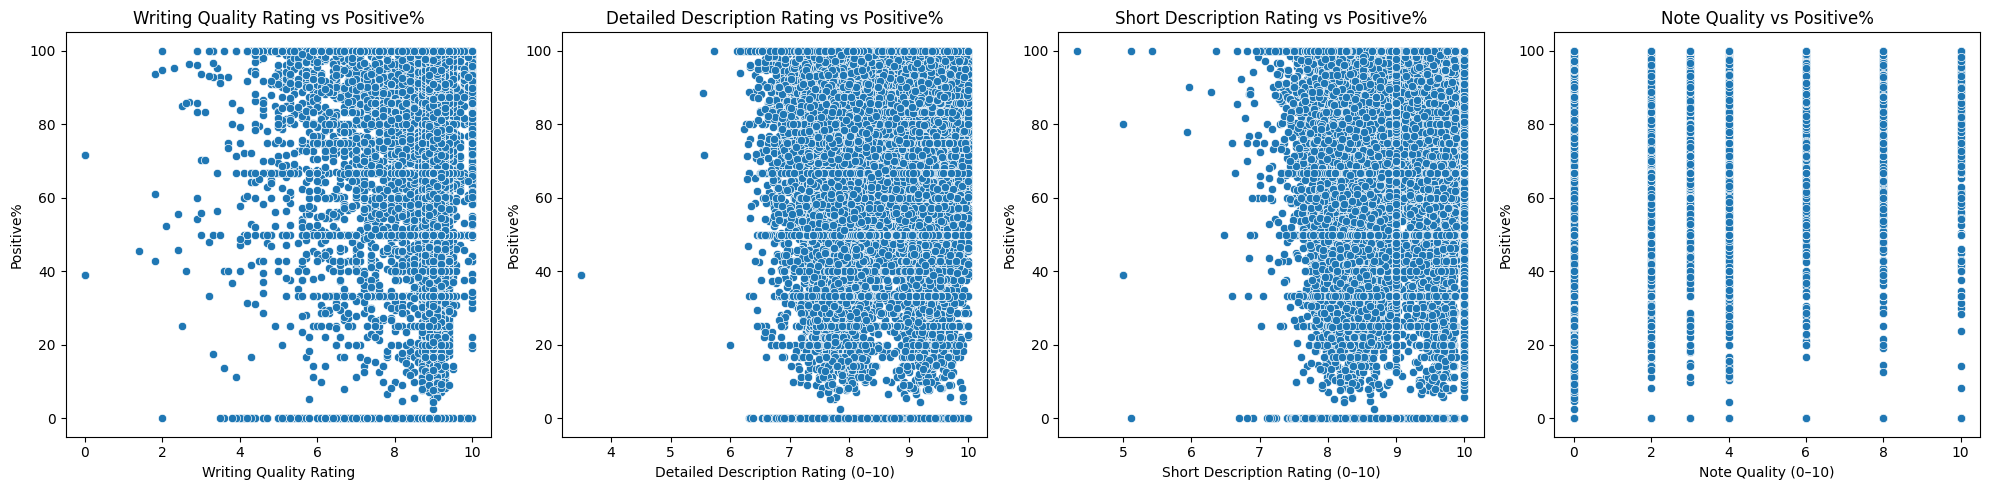

In [ ]:
plt.figure(figsize=(20, 5))  # Adjust figure size for better side-by-side display

# Subplot 1: Writing Quality Rating vs Positive%
plt.subplot(1, 4, 1)
sns.scatterplot(x='Writing Quality Rating', y='Positive%', data=steam_df)
plt.title('Writing Quality Rating vs Positive%')

# Subplot 2: Detailed Description Rating vs Positive%
plt.subplot(1, 4, 2)
sns.scatterplot(x='Detailed Description Rating (0–10)', y='Positive%', data=steam_df)
plt.title('Detailed Description Rating vs Positive%')

# Subplot 3: Short Description Rating vs Positive%
plt.subplot(1, 4, 3)
sns.scatterplot(x='Short Description Rating (0–10)', y='Positive%', data=steam_df)
plt.title('Short Description Rating vs Positive%')

# Subplot 4: Note Quality vs Positive%
plt.subplot(1, 4, 4)
sns.scatterplot(x='Note Quality (0–10)', y='Positive%', data=steam_df)
plt.title('Note Quality vs Positive%')


plt.tight_layout() # Adjust spacing between subplots
plt.show()

In [ ]:
steam_df.head()

,Peak CCU,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Note Quality (0–10),Writing Quality Rating,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,Detailed Description Rating (0–10),Short Description Rating (0–10),Positive%,Num games published by publisher,Num games developed by developer,Years old,Number of Categories,Number of Genres,Number of Tags,Number of Supported Languages,Number of Audio Languages,Estimated_owners_0 - 20000,Estimated_owners_100000 - 200000,Estimated_owners_1000000 - 2000000,Estimated_owners_10000000 - 20000000,Estimated_owners_100000000 - 200000000,Estimated_owners_20000 - 50000,Estimated_owners_200000 - 500000,Estimated_owners_2000000 - 5000000,Estimated_owners_20000000 - 50000000,Estimated_owners_50000 - 100000,Estimated_owners_500000 - 1000000,Estimated_owners_5000000 - 10000000,Estimated_owners_50000000 - 100000000,Season_Fall,Season_Spring,Season_Summer,Season_Winter
0,0,0,0.99,0,0,True,True,False,0,0,12,0,0,0,0,0,0,8.8,86.0,68.0,-1.0,-1.0,9.23,9.40,91.379310,5,4,8,7,2,20,152,2,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,0,0,5.99,0,0,True,True,True,0,0,0,0,0,0,0,0,0,9.4,-1.0,-1.0,-1.0,-1.0,9.80,8.10,100.000000,1,1,5,2,3,19,153,2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,0,0,0.00,0,0,True,True,False,0,0,17,0,0,0,0,0,6,9.0,89.0,65.0,-1.0,-1.0,9.30,9.00,86.206897,1,1,5,2,2,6,30,2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,68,0,0.00,0,0,True,False,False,0,0,0,0,0,0,0,0,0,9.2,63.0,257.0,-1.0,-1.0,7.93,8.76,63.970588,1,1,4,8,6,20,11,2,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
4,3,0,10.99,0,1,True,False,False,0,0,62,0,0,0,0,0,0,9.1,69.0,26.0,-1.0,-1.0,9.31,8.58,75.000000,1,1,3,3,2,20,32,2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


Next, we wanted to evaluate why our initial columns did not help with predicting the postive%. After visualizing them, we found that these columns have a lot of observations with 0 values. While there is a positive relationship with columns we would expect, such as Peak CCU, Metacritic Score, User score, Achievements, and Reccomendations, the high number of 0 values leads to a not strong pattern between them and the response variable. This explains why our initial attemtpt did not see a dramatic decrease in RMSE.

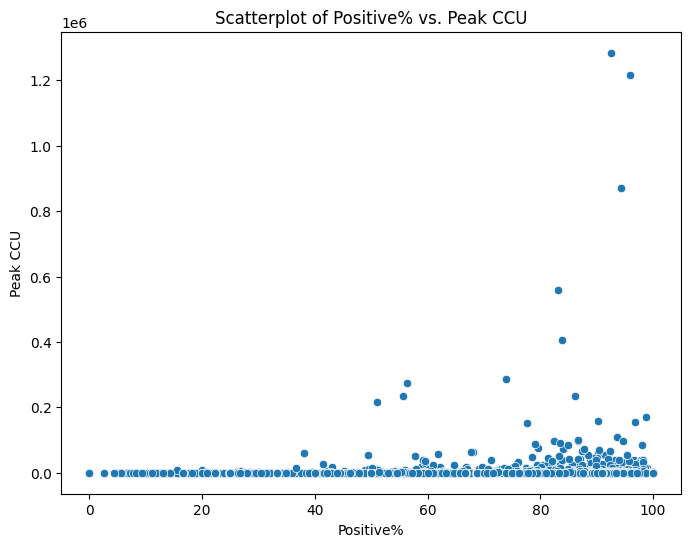

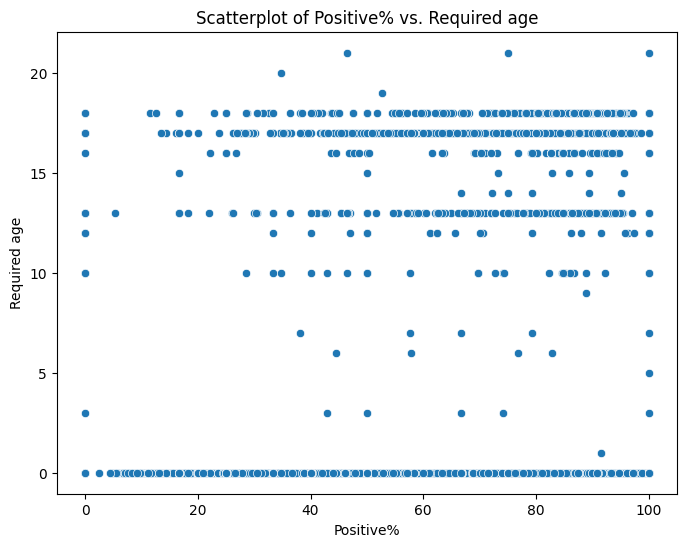

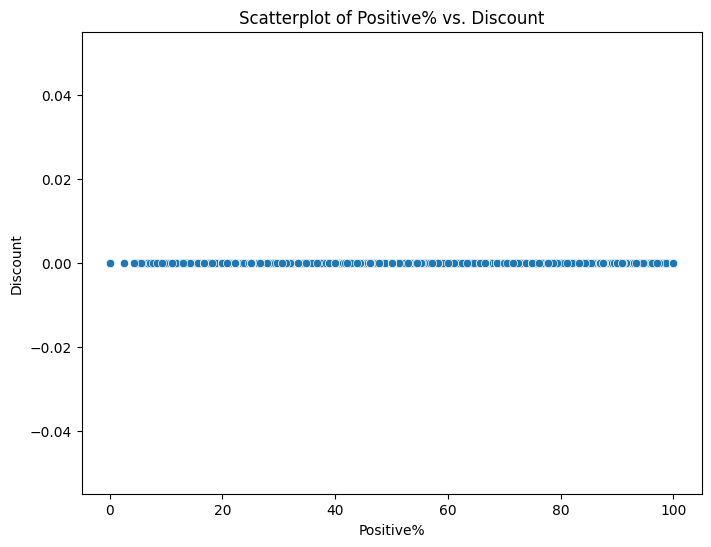

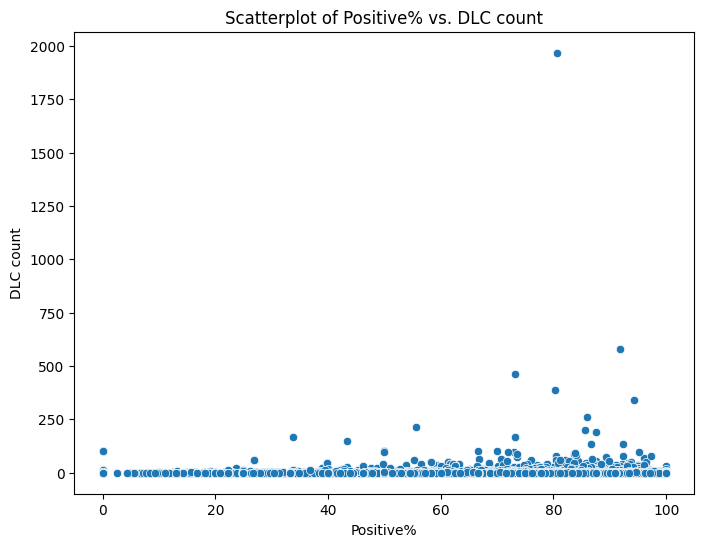

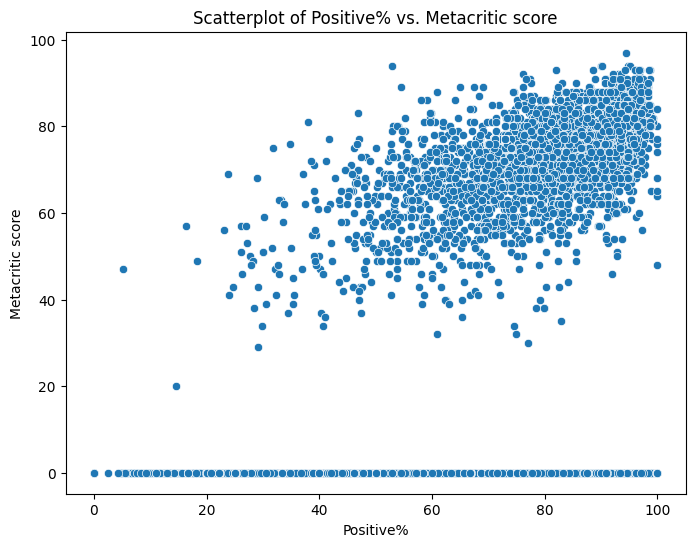

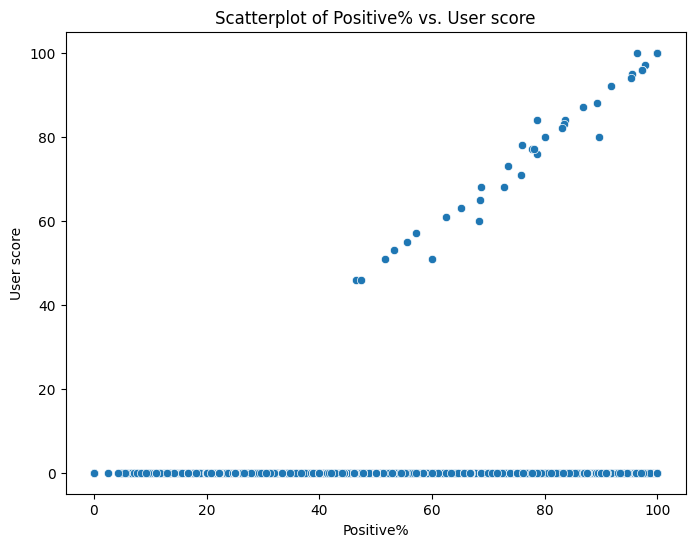

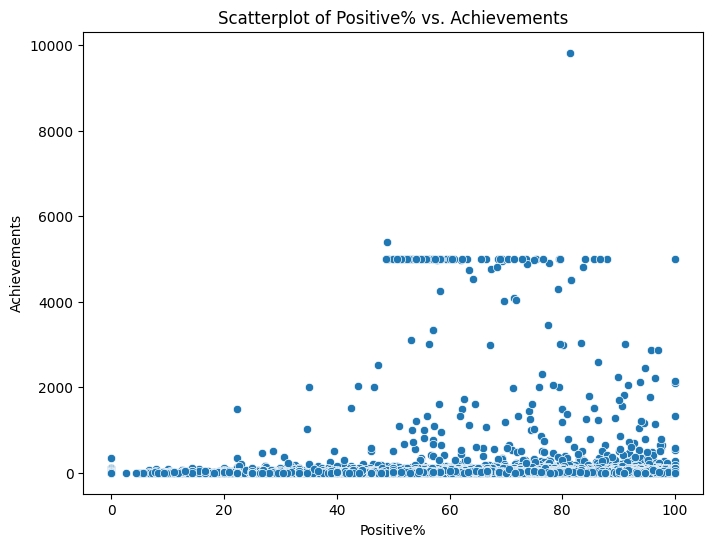

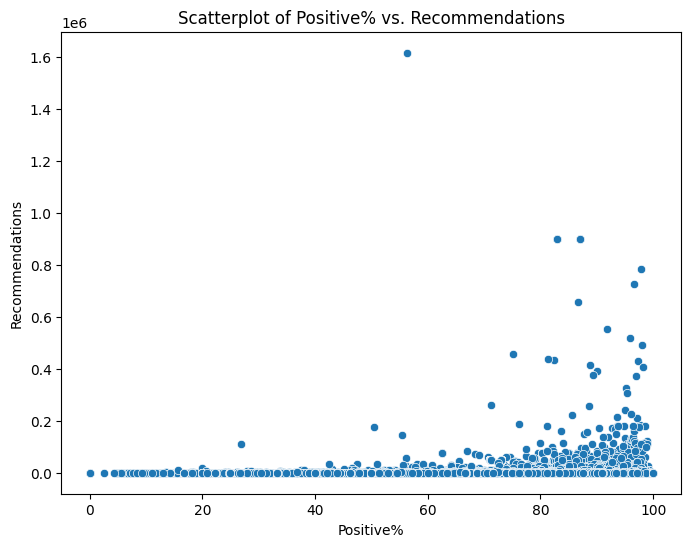

In [ ]:
cols_to_plot = ['Peak CCU', 'Required age', 'Discount', 'DLC count', 'Metacritic score', 'User score', 'Achievements', 'Recommendations']

for col in cols_to_plot:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='Positive%', y=col, data=steam_df)
    plt.title(f'Scatterplot of Positive% vs. {col}')
    plt.xlabel('Positive%')
    plt.ylabel(col)
    plt.show()

Finally, we wanted to identify the correlation between price and positive% but we found that there is not much a strong pattern between them.

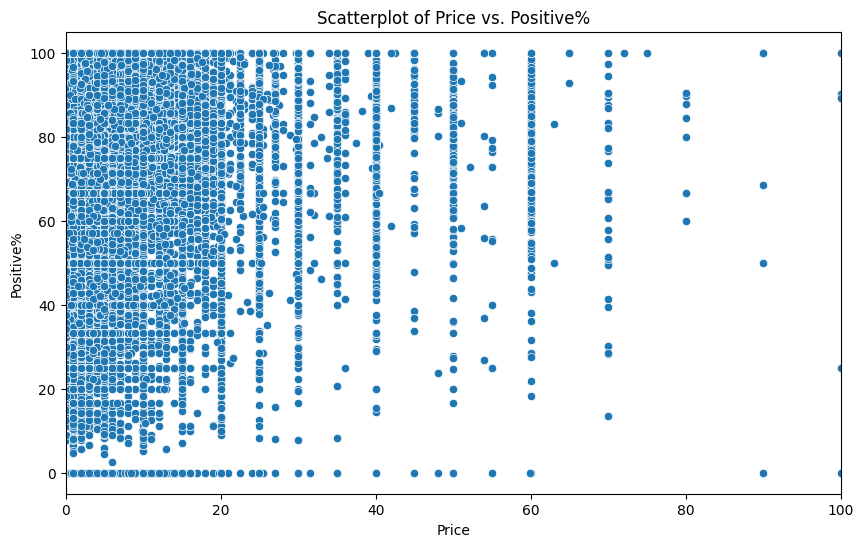

In [ ]:
# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Price', y='Positive%', data=steam_df)
plt.title('Scatterplot of Price vs. Positive%')
plt.xlabel('Price')
plt.ylabel('Positive%')

# Set the x-axis limits to 0 and 100
plt.xlim(0, 100)

plt.show()

## **Regression Model Testing**

Below are the models we have decided to use for our analysis.

####Definign X and Y(training and test sets)

In [ ]:
#Define x and y
X=steam_df.drop(['Positive%'],axis=1)
y=steam_df['Positive%']

#Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

print(X.shape)
print(X.dtypes)

# Standardize the data
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(59425, 49)
Peak CCU                                    int64
Required age                                int64
Price                                     float64
Discount                                    int64
DLC count                                   int64
Windows                                      bool
Mac                                          bool
Linux                                        bool
Metacritic score                            int64
User score                                  int64
Achievements                                int64
Recommendations                             int64
Average playtime forever                    int64
Average playtime two weeks                  int64
Median playtime forever                     int64
Median playtime two weeks                   int64
Note Quality (0–10)                         int64
Writing Quality Rating                    float64
pct_pos_total                             float64
num_reviews_total                     

###Benchmark

In [ ]:
# Calculate the average of 'Positive%' in y_train
average_positive_percentage_train = y_train.mean()

# Predict all values in y_test as the average of y_train
predictions = [average_positive_percentage_train] * len(y_test)

print(average_positive_percentage_train)

# Calculate RMSE
rmse = math.sqrt(mean_squared_error(y_test, predictions))
print(f"RMSE using average of y_train: {rmse}")
print(predictions)

75.79104963969577
RMSE using average of y_train: 24.040817852402565
[np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), np.float64(75.79104963969577), n

###KNN-regressor

To start off with, we tried a simple KNN-regressor model, with number of neighbors at 20, just to get a feel for its performance.

In [ ]:
# Initialize and train the KNN regressor with scaled data
knn_regressor_scaled = KNeighborsRegressor(n_neighbors=20) # You can adjust the number of neighbors
knn_regressor_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_scaled = knn_regressor_scaled.predict(X_test_scaled)

# Calculate RMSE for the scaled data
rmse_scaled = math.sqrt(mean_squared_error(y_test, y_pred_scaled))
print(f"KNN RMSE (Scaled Data): {rmse_scaled}")

KNN RMSE (Scaled Data): 21.644347963484012


When tunning our paramter(number of neighbors), we could not just use the range(0, lenght of training set) because it was too computationally intensive. Instead, we decided to use values in ranges of 10(i.e 0-10, 10-20, etc.). After trying a lot of combinations, we found that the range of 30-40 gives us the best results. When testing we used cross validation with cv=5. This helps us get the number of neighbors that gives the most generalizable model(i.e. one that does not have drastically different resutls based on changes in the test data). The model below showed that the best number of neighbors is 34.

In [ ]:
# Define the parameter grid for n_neighbors
param_grid = {'n_neighbors': np.arange(30,40)}  # Test n_neighbors from 31 to 40

# Create a KNN regressor
knn = KNeighborsRegressor()

# Create a GridSearchCV object
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_root_mean_squared_error')

# Fit the GridSearchCV object to the data
grid_search.fit(X_train_scaled, y_train)

# Print the best hyperparameters and best score
print("Best hyperparameters:", grid_search.best_params_)
print("Best Cross Validation average RMSE:", -grid_search.best_score_)

# Get the best model
best_knn = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_knn.predict(X_test_scaled)

# Evaluate the best model
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE of best model:", rmse)
knn = KNeighborsRegressor()

Best hyperparameters: {'n_neighbors': np.int64(34)}
Best Cross Validation average RMSE: 21.871436678482908
Test RMSE of best model: 21.60808561987454


In [ ]:
#Aggreagating the results from the cross validation.

# Get the results from the grid search
cv_results = grid_search.cv_results_

# Extract the number of neighbors and their corresponding mean test scores
n_neighbors = param_grid['n_neighbors']
mean_test_scores = -cv_results['mean_test_score'] # Negate because scoring is neg_root_mean_squared_error

# Create a DataFrame for better visualization
results_df = pd.DataFrame({'Number of Neighbors': n_neighbors, 'Cross Validation Average RMSE': mean_test_scores})

# Display the DataFrame
results_df


,Number of Neighbors,Cross Validation Average RMSE
0,30,21.882372
1,31,21.875608
2,32,21.874243
3,33,21.874122
4,34,21.871437
5,35,21.878044
6,36,21.883235
7,37,21.887360
8,38,21.889550
9,39,21.888939


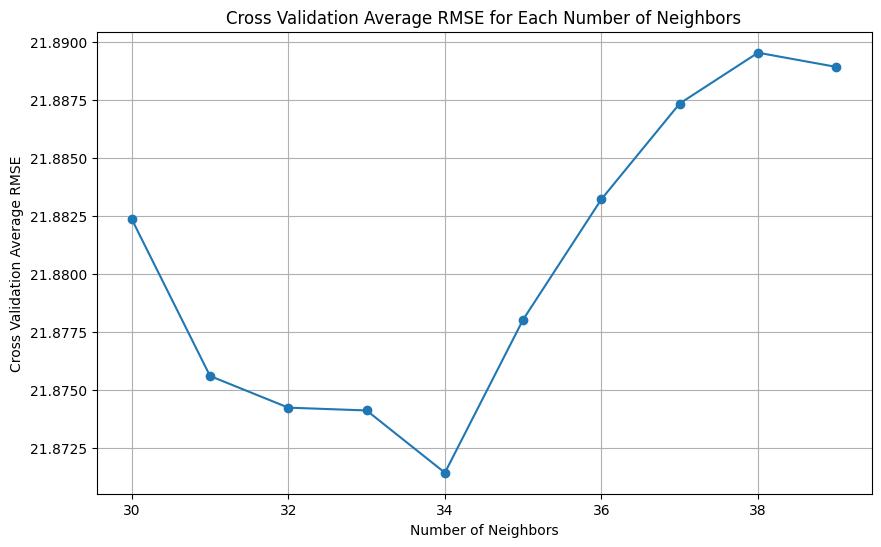

In [ ]:
#Showing the results in the graph
plt.figure(figsize=(10, 6))
plt.plot(results_df['Number of Neighbors'], results_df['Cross Validation Average RMSE'], marker='o')
plt.xlabel('Number of Neighbors')
plt.ylabel('Cross Validation Average RMSE')
plt.title('Cross Validation Average RMSE for Each Number of Neighbors')
plt.grid(True)
plt.show()

We have also plotted the range test mses for our current test set based on the same range that we used for cross validaiton. Here, the best result is n_neighbors=31, but as we mentioned previously, the model could be highly sensitive to changes in test data if we use this parameter, so we still used n_neighbors=34.

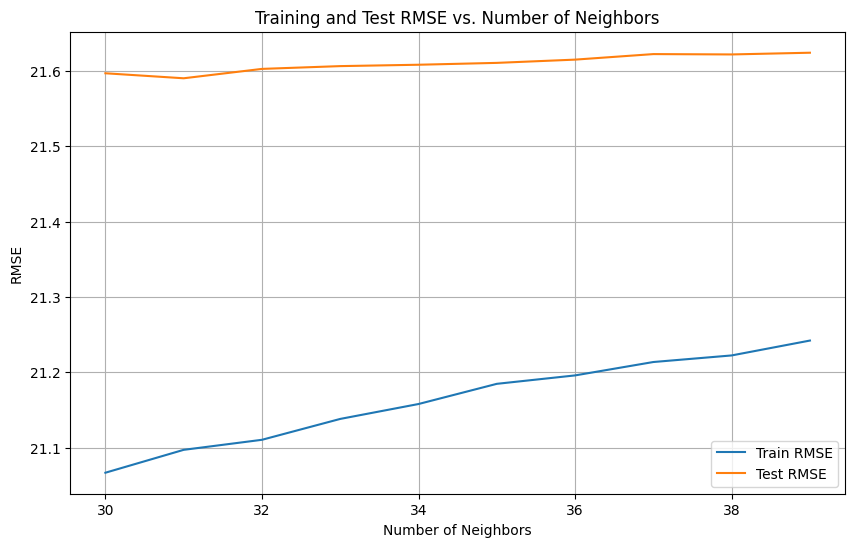

In [ ]:
# Training RMSE
train_rmse_values = []
neighbors = np.arange(30,40)

for n in neighbors:
    knn = KNeighborsRegressor(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    y_pred_train = knn.predict(X_train_scaled)
    rmse_train = math.sqrt(mean_squared_error(y_train, y_pred_train))
    train_rmse_values.append(rmse_train)

# Test RMSE
test_rmse_values = []
for n in neighbors:
    knn = KNeighborsRegressor(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    y_pred_test = knn.predict(X_test_scaled)
    rmse_test = math.sqrt(mean_squared_error(y_test, y_pred_test))
    test_rmse_values.append(rmse_test)


# Plotting
plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_rmse_values, label="Train RMSE")
plt.plot(neighbors, test_rmse_values, label="Test RMSE")
plt.xlabel("Number of Neighbors")
plt.ylabel("RMSE")
plt.title("Training and Test RMSE vs. Number of Neighbors")
plt.legend()
plt.grid(True)
plt.show()

###Decision Trees

####Base Decision Tree

For Decisiion Trees, we started by applying the model with base estimators to see how it would work. The model performed worse than the benchmark, likely due to overfitting to the training dataset.

In [ ]:
# Initialize and train the decision tree regressor
dt_regressor = DecisionTreeRegressor(random_state=1)  # You can tune hyperparameters here
dt_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_regressor.predict(X_test)

# Evaluate the model
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Decision Tree RMSE: {rmse}")

Decision Tree RMSE: 26.64151861871693


We also tested if scaling the data would have any impact, but threre was no change.

In [ ]:
# Identify numerical features
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Now use X_train_scaled and X_test_scaled for your decision tree model
dt_regressor = DecisionTreeRegressor(random_state=1)
dt_regressor.fit(X_train_scaled, y_train)
y_pred = dt_regressor.predict(X_test_scaled)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Decision Tree RMSE (Scaled Data): {rmse}")

Decision Tree RMSE (Scaled Data): 26.67184709442873


####Using Cross Validation to find Alpha

Next, we wanted to prune the tree, to see by how much the model improve and reduce the RMSE. We have retrieved the alphas using the function in class. Unfortunately, we got around 24284 alphas, which is too compuationally intensive, so we used a subset of these alphas. After some testing, we found that the later values of alpha yielded better scores, so we decided to go with them. Here, we decided to use cross validation to help decide which alpha to use, to get a better more generalizable model. After finishing the cross validation, we found that alpha 0.5456854699992348 is the most optimal with a cross validation score of 19.58, and a test MSE score of 19.37(Way better than the base decision tree model!).

In [ ]:
#Retrtieving the alphas to use
alphas = dt_regressor.cost_complexity_pruning_path(X_train, y_train).ccp_alphas

#Defining a subset of alphas
sampled_alphas_untuned=alphas[24240:]

#Empty list which will store our trees
dt_per_alpha_untuned=[]

#Loop through the alphas and store each decison tree into our list
for alpha in sampled_alphas_untuned:
    dt_regressor = DecisionTreeRegressor(random_state=1, ccp_alpha=alpha)
    dt_regressor.fit(X_train, y_train)
    dt_per_alpha_untuned.append(dt_regressor)

In [ ]:
# Calculate cross-validation scores for each tree
cv_scores = [cross_val_score(dt, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean() for dt in dt_per_alpha_untuned]

# Find the best tree based on cross-validation score
best_index = np.argmin(-np.array(cv_scores))  # Negate since scores are negative RMSE
best_tree = dt_per_alpha_untuned[best_index]
best_alpha = sampled_alphas_untuned[best_index]

# Calculate test RMSE for the best tree
y_pred = best_tree.predict(X_test)
test_rmse = math.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print(f"Best alpha: {best_alpha}")
print(f"Best cross-validation score (negative RMSE): {-cv_scores[best_index]}")
print(f"Test RMSE for the best tree: {test_rmse}")

Best alpha: 0.5456854699992348
Best cross-validation score (negative RMSE): 19.584644099775726
Test RMSE for the best tree: 19.37191240239982


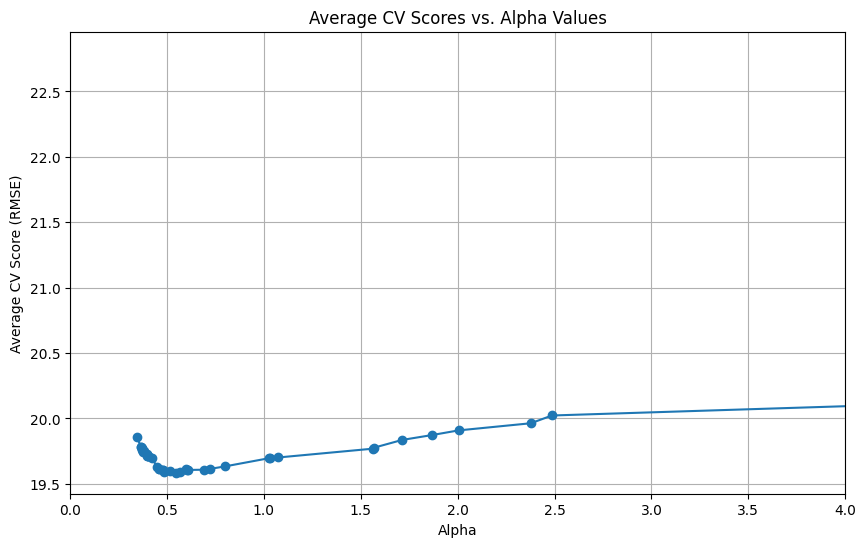

In [ ]:
# Create a DataFrame to store the alpha values and their corresponding cross-validation scores.
df_results_untuned = pd.DataFrame({'alpha': sampled_alphas_untuned, 'cv_scores': cv_scores})

# Plot the average cross-validation scores against the alpha values.
plt.figure(figsize=(10, 6))
plt.plot(df_results_untuned['alpha'], -df_results_untuned['cv_scores'], marker='o')  # Negate cv_scores for RMSE
plt.xlabel('Alpha')
plt.ylabel('Average CV Score (RMSE)')
plt.xlim(0,4)
plt.title('Average CV Scores vs. Alpha Values')
plt.grid(True)
plt.show()

In [ ]:
# Display the DataFrame with alphas and their RMSE scores(negative due to the nature of cross validation)
df_results_untuned

,alpha,cv_scores
0,0.343174,-19.861237
1,0.366596,-19.778414
2,0.367068,-19.778414
3,0.368596,-19.775776
4,0.372433,-19.755617
5,0.373546,-19.742878
6,0.379464,-19.747148
7,0.394539,-19.729309
8,0.398690,-19.716236
9,0.401120,-19.716017


####Tuned Decision Tree

After pruning the base tree, we experimented with the other hyper parameters of Decision trees: max_depth, min_samples_split, min_samples_leaf, and min_impurity_decrease. We defined the lists of possible values for each of these and conducted cross validation to choose the best ones to use for our tuned decision tree model. After the cross validation was complete, the best paramter values were the following: {'max_depth': 10, 'min_impurity_decrease': 0.05, 'min_samples_leaf': 8, 'min_samples_split': 20}. The resulting cross validation score was 19.8(behind the pruned base Decsion tree model).

In [ ]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [None, 10, 20, 30,40,50],
    'min_samples_split': [2, 5, 10,20],
    'min_samples_leaf': [1, 2, 4,8],
    'min_impurity_decrease': [0.0, 0.01, 0.02,0.03,0.04,0.05]

}

# Initialize the decision tree regressor
dt_regressor = DecisionTreeRegressor(random_state=1)

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=dt_regressor, param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_dt_regressor = grid_search.best_estimator_
best_score_dt = grid_search.best_score_

print("Best hyperparameters:", best_params)
print("Best cross-validation score (RMSE):", -best_score_dt)
print("Best cross-validation RMSE:", np.sqrt(-best_score_dt))



# Evaluate the best model on the test set
y_pred = best_dt_regressor.predict(X_test_scaled)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Decision Tree RMSE (Scaled Data, Tuned): {rmse}")


Best hyperparameters: {'max_depth': 10, 'min_impurity_decrease': 0.05, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best cross-validation score (RMSE): 19.80466253328128
Best cross-validation RMSE: 4.450242974634226
Decision Tree RMSE (Scaled Data, Tuned): 19.41714250629963


####Pruning Tuned Decision Tree

After getting a tuned decision tree model, we wondered if pruning this tree could further decrease the test RMSE. We used cross-validation, to determine the best possible alpha and found that the alpha is 0.5456854699970322 which is around the same as the alpha for the untuned tree. The average cross validation score here is about the same as that of the base pruned decision tree. However, this is still significantly better than the benchmark!

In [ ]:
#Getting the alphas for the tuned tree and fitting trees for each 5th alpha

#Retrieve the alphas
alphas = best_dt_regressor.cost_complexity_pruning_path(X_train, y_train).ccp_alphas


#Define an empty list for storing our results
dt_per_alpha=[]

#Loop through each sampled_alpha and fit the decision tree.
for alpha in alphas:
    dt_regressor = DecisionTreeRegressor(random_state=1, ccp_alpha=alpha, **best_params)
    dt_regressor.fit(X_train, y_train)
    dt_per_alpha.append(dt_regressor)

In [ ]:
# Calculate cross-validation scores for each tree
cv_scores = [cross_val_score(dt, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean() for dt in dt_per_alpha]

# Find the best tree based on cross-validation score
best_index = np.argmin(-np.array(cv_scores))  # Negate since scores are negative RMSE
best_tree = dt_per_alpha[best_index]
best_alpha = alphas[best_index]

# Calculate test RMSE for the best tree
y_pred = best_tree.predict(X_test)
test_rmse = math.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print(f"Best alpha: {best_alpha}")
print(f"Best cross-validation score (negative RMSE): {-cv_scores[best_index]}")
print(f"Test RMSE for the best tree: {test_rmse}")


Best alpha: 0.5456854699970322
Best cross-validation score (negative RMSE): 19.584644099775726
Test RMSE for the best tree: 19.371912402399815


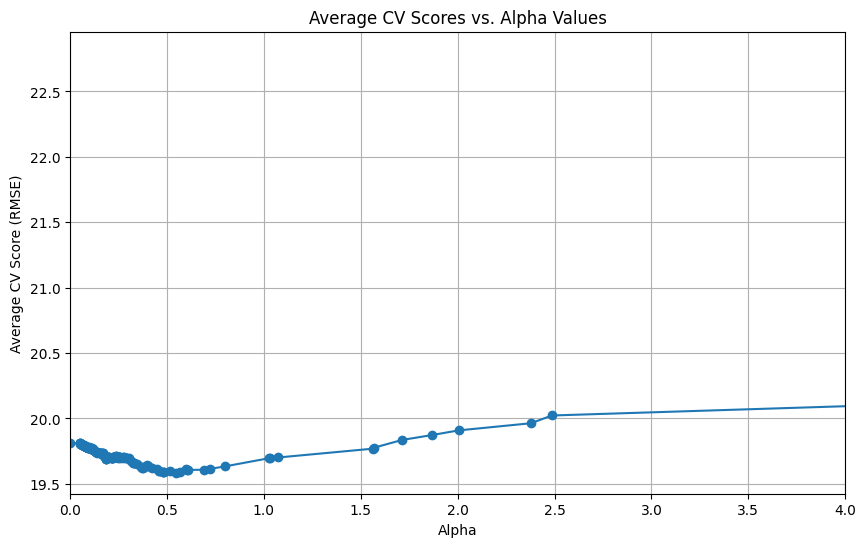

In [ ]:
#Visualizing the alphas and cross validaiton scores for the tuned model


# Create a DataFrame to store the results
df_results = pd.DataFrame({'alpha': alphas, 'cv_scores': cv_scores}) # Define df_results



plt.figure(figsize=(10, 6))
plt.plot(df_results['alpha'], -df_results['cv_scores'], marker='o')  # Negate cv_scores for RMSE
plt.xlim(0,4)
plt.xlabel('Alpha')
plt.ylabel('Average CV Score (RMSE)')
plt.title('Average CV Scores vs. Alpha Values')
plt.grid(True)
plt.show()

####Decision Tree visualization

Finally, we visualized the final tuned and pruned decision tree we obtained. We did not try to visualize the untuned tree because it would be too deep and incomprehensible. We visualized the tuned tree by using both dtreeviz and the base tree plot method. We defined the tuned and pruned decision tree below.

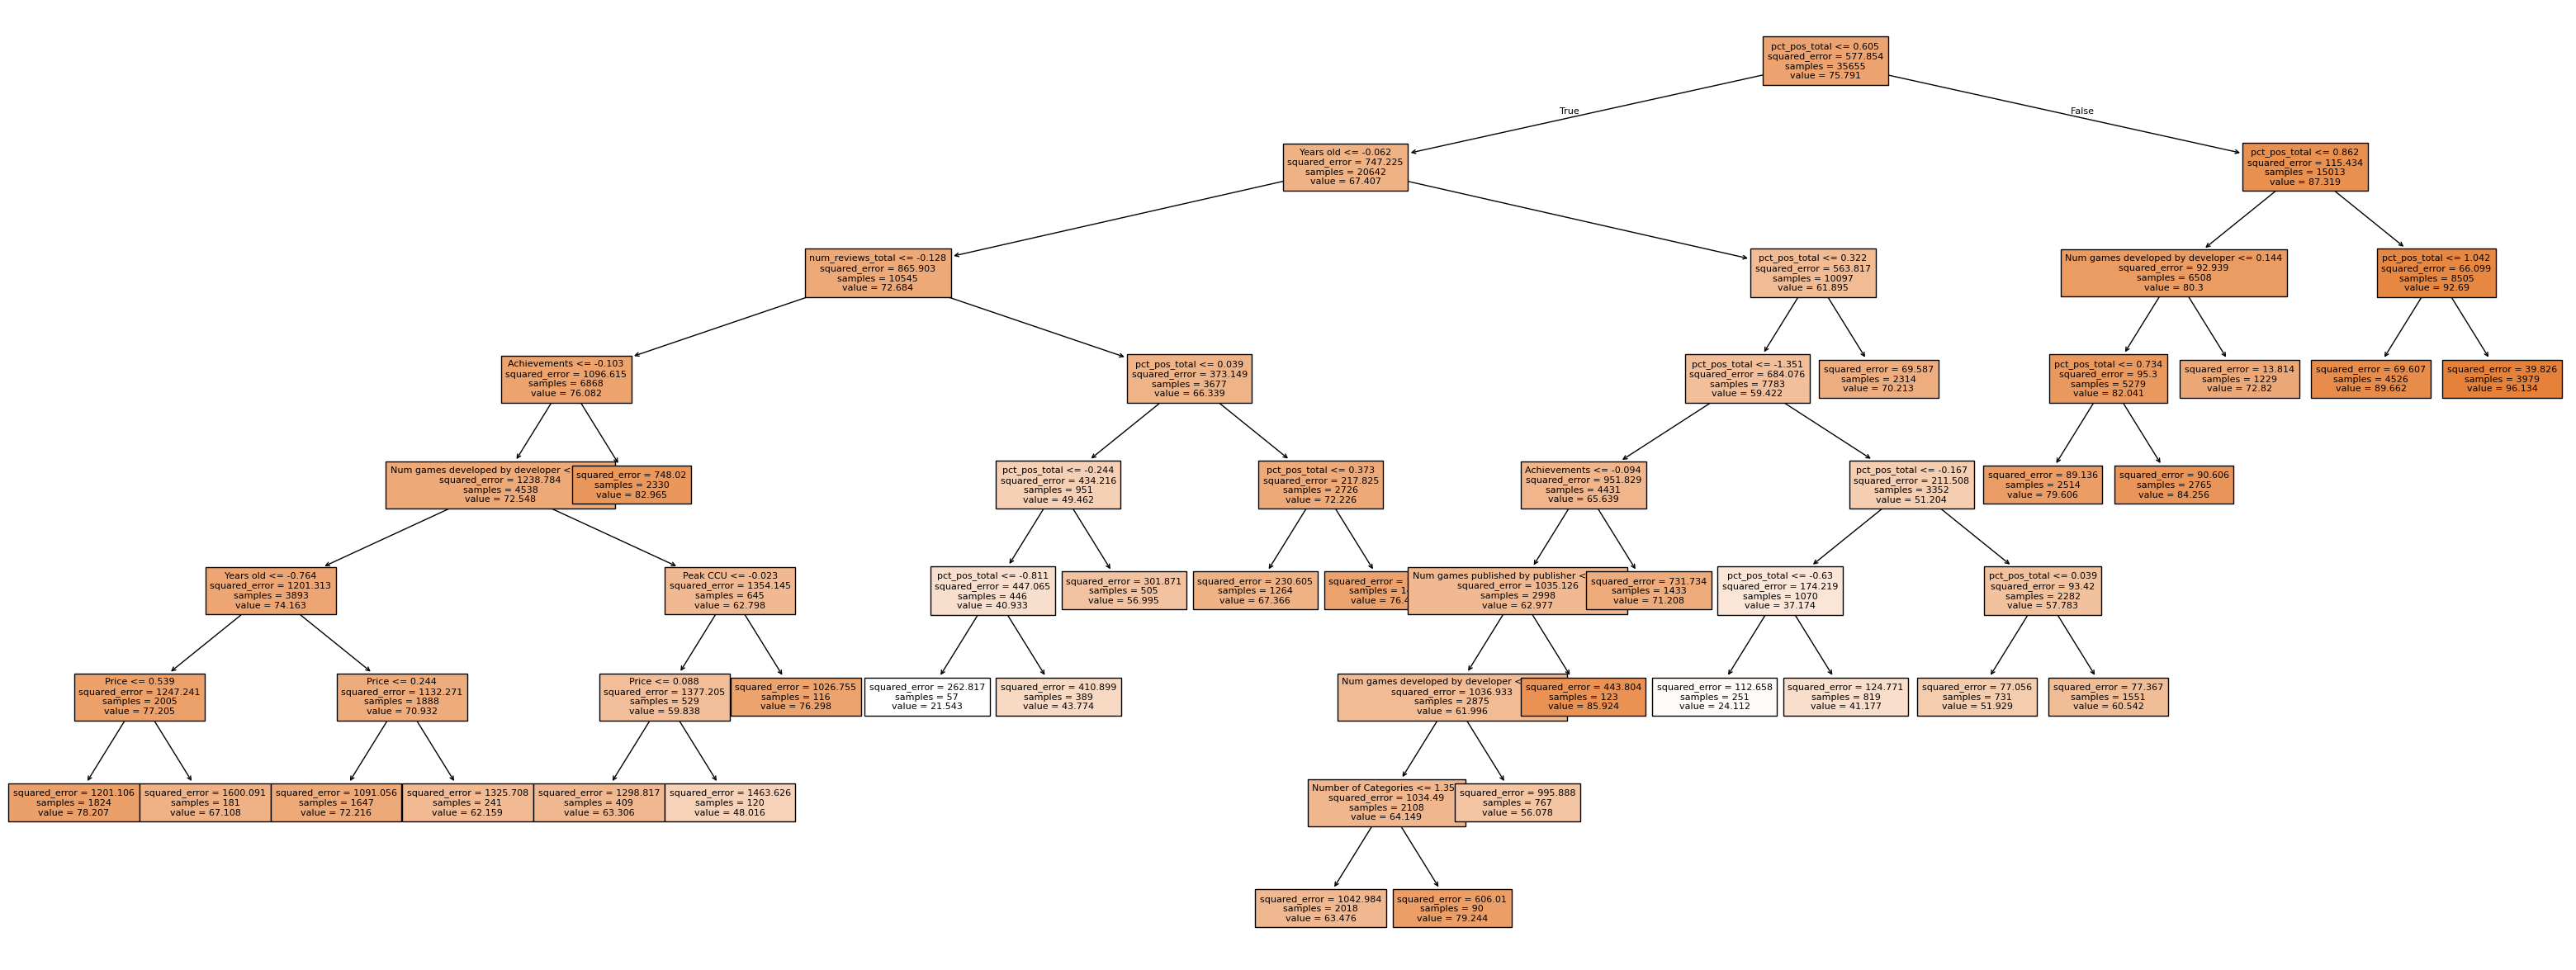

In [ ]:
#Defining the pruned and tuned tree
best_dt_regressor_pruned= DecisionTreeRegressor(ccp_alpha=best_alpha,**best_params)
best_dt_regressor_pruned.fit(X_train_scaled, y_train)


#Visualizing the tree using the built-in function
plt.figure(figsize=(40,15))

tree.plot_tree(best_dt_regressor_pruned,
               feature_names=X_train_scaled.columns,
               filled=True,
               fontsize=8)
plt.show()

In [ ]:
# https://github.com/parrt/dtreeviz/blob/master/notebooks/dtreeviz_sklearn_visualisations.ipynb
%%capture
!pip install dtreeviz
import dtreeviz

viz = dtreeviz.model(best_dt_regressor_pruned,
               X_train_scaled,
               y_train,
               feature_names=X_train_scaled.columns,
               target_name='Positive%')

In [ ]:
viz.view(scale=1, fontname='DejaVu Sans')

Output hidden; open in https://colab.research.google.com to view.

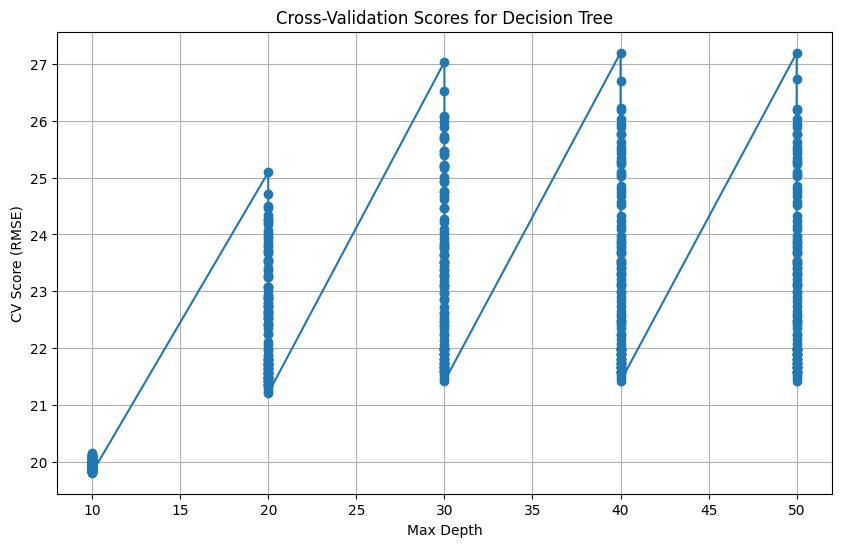

In [ ]:
# Access the results from the grid search
cv_results = grid_search.cv_results_

# Extract the max_depth values and their corresponding mean test scores
max_depths = [param['max_depth'] for param in grid_search.cv_results_['params']]
mean_test_scores = -cv_results['mean_test_score'] # Negate because scoring is neg_root_mean_squared_error

# Create a DataFrame for better visualization
results_df = pd.DataFrame({'Max Depth': max_depths, 'CV Score (RMSE)': mean_test_scores})

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(results_df['Max Depth'], results_df['CV Score (RMSE)'], marker='o')
plt.xlabel('Max Depth')
plt.ylabel('CV Score (RMSE)')
plt.title('Cross-Validation Scores for Decision Tree')
plt.grid(True)
plt.show()

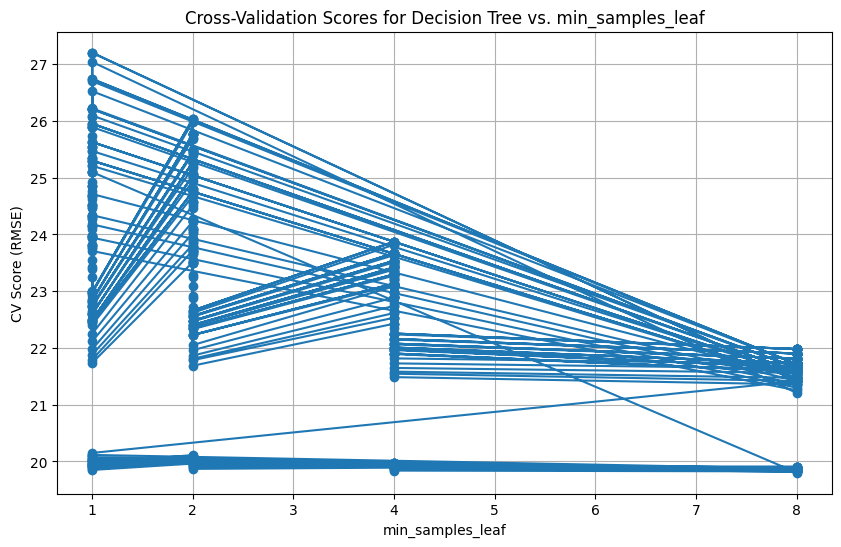

In [ ]:
# Access the results from the grid search
cv_results = grid_search.cv_results_

# Extract the min_samples_leaf values and their corresponding mean test scores
min_samples_leaf_values = [param['min_samples_leaf'] for param in grid_search.cv_results_['params']]
mean_test_scores = -cv_results['mean_test_score'] # Negate because scoring is neg_root_mean_squared_error


# Create a DataFrame for better visualization (optional but helpful)
results_df = pd.DataFrame({'min_samples_leaf': min_samples_leaf_values, 'CV Score (RMSE)': mean_test_scores})

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(results_df['min_samples_leaf'], results_df['CV Score (RMSE)'], marker='o')
plt.xlabel('min_samples_leaf')
plt.ylabel('CV Score (RMSE)')
plt.title('Cross-Validation Scores for Decision Tree vs. min_samples_leaf')
plt.grid(True)
plt.show()

###Random Forests

####Random Forest Base Model

Random Forests performed the best out of all our models with the base model achieving an RMSE of 19. For this case, we set the n_estimators(number of trees) to 100, since that is the reccomended number for most cases.

In [ ]:
# Initialize and train the random forest regressor
rf_regressor = RandomForestRegressor(random_state=1, n_estimators=100)  # You can adjust the number of estimators and other hyperparameters
rf_regressor.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_regressor.predict(X_test_scaled)

# Calculate RMSE for the random forest model
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest RMSE (Scaled Data): {rmse_rf}")

Random Forest RMSE (Scaled Data): 19.004273498365457


In [ ]:
# Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=1)

# Perform cross-validation
cv_scores = cross_val_score(rf_regressor, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')

# Calculate RMSE for each fold
rmse_scores = -cv_scores

# Print the RMSE scores for each fold
print("RMSE scores for each fold:", rmse_scores)

# Print the average RMSE across all folds
print(f"Average CV RMSE across all folds: {np.mean(rmse_scores)}")

RMSE scores for each fold: [19.02672896 18.81398955 19.32113786 19.73132918 19.50438845]
Average RMSE across all folds: 19.279514800734127


####Random Forest Tuned Model

We have also attempted to tune our Random Forest by using multiple grid search cross validations and found that the best one was the second tuned model. We could not do all of the possible values in one Grid search CV because of the computational intensity, so we split them into 3 different models with different parameters. The second model had the following hyperparameters: (ccp_alpha': 0, 'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 5).

In [ ]:
# Define the parameter grid for RandomForestRegressor
param_grid_rf = {
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt',0.5,0.33],
    'ccp_alpha': [0.0, 0.5, 1]  # Cost complexity pruning parameter
}

# Initialize the RandomForestRegressor
rf_regressor = RandomForestRegressor(random_state=1)

# Perform GridSearchCV
grid_search_rf1 = GridSearchCV(estimator=rf_regressor, param_grid=param_grid_rf, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_rf1.fit(X_train_scaled, y_train)

# Get the best hyperparameters and the best model
best_params_rf1 = grid_search_rf1.best_params_
best_rf_regressor1 = grid_search_rf1.best_estimator_
best_score_rf1 = grid_search_rf1.best_score_

print("Best hyperparameters:", best_params_rf1)
print("Best cross-validation score (RMSE):", -best_score_rf1)
print("Best cross-validation RMSE:", np.sqrt(-best_score_rf1))


Best hyperparameters: {'ccp_alpha': 0.0, 'max_depth': 20, 'max_features': 0.33, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best cross-validation score (RMSE): 19.011914655656234
Best cross-validation RMSE: 4.360265434082682


In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestRegressor
param_grid_rf = {
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2,3],
    'max_features': ['sqrt',0.5,0.33],
    'ccp_alpha': [0, 0.5, 1]  # Cost complexity pruning parameter
}

# Initialize the RandomForestRegressor
rf_regressor = RandomForestRegressor(random_state=1)

# Perform GridSearchCV
grid_search_rf2 = GridSearchCV(estimator=rf_regressor, param_grid=param_grid_rf, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_rf2.fit(X_train_scaled, y_train)

# Get the best hyperparameters and the best model
best_params_rf2 = grid_search_rf2.best_params_
best_rf_regressor2 = grid_search_rf2.best_estimator_
best_score_rf2 = grid_search_rf2.best_score_

print("Best hyperparameters:", best_params_rf2)
print("Best cross-validation score (RMSE):", -best_score_rf2)
print("Best cross-validation RMSE:", np.sqrt(-best_score_rf2))

Best hyperparameters: {'ccp_alpha': 0, 'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 5}
Best cross-validation score (RMSE): 18.997673853553717
Best cross-validation RMSE: 4.358632108076308


In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestRegressor
param_grid_rf = {
    'max_depth': [25,30,35],
    'min_samples_split': [15, 20],
    'min_samples_leaf': [4,5],
    'max_features': ['sqrt',0.5,0.33],
    'ccp_alpha': [0, 0.5]  # Cost complexity pruning parameter
}

# Initialize the RandomForestRegressor
rf_regressor = RandomForestRegressor(random_state=1)

# Perform GridSearchCV
grid_search_rf3 = GridSearchCV(estimator=rf_regressor, param_grid=param_grid_rf, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_rf3.fit(X_train_scaled, y_train)

# Get the best hyperparameters and the best model
best_params_rf3 = grid_search_rf3.best_params_
best_rf_regressor3 = grid_search_rf3.best_estimator_
best_score_rf3 = grid_search_rf3.best_score_

print("Best hyperparameters:", best_params_rf3)
print("Best cross-validation score (RMSE):", -best_score_rf3)
print("Best cross-validation RMSE:", np.sqrt(-best_score_rf3))

Best hyperparameters: {'ccp_alpha': 0, 'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best cross-validation score (RMSE): 19.012212463984742
Best cross-validation RMSE: 4.360299584201153


####Visualizations Based on the Best Random Forest Model(Second Tuned).

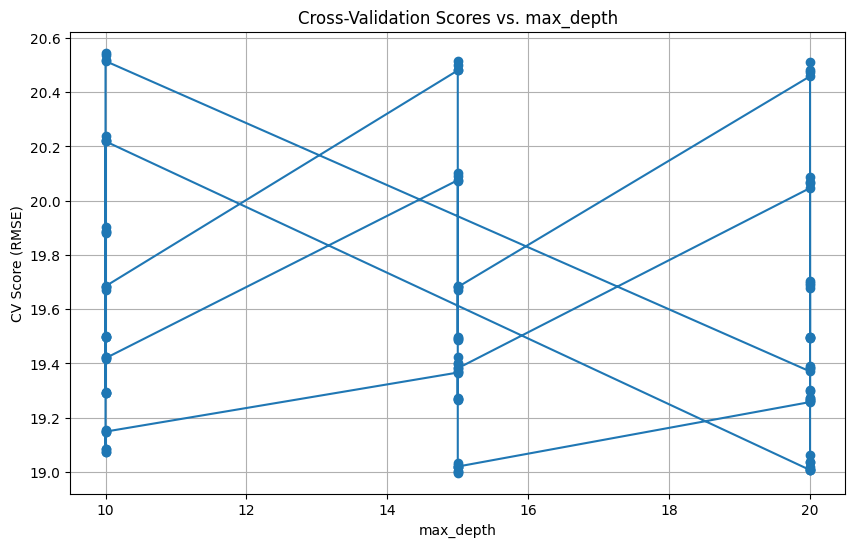

In [ ]:
# Extract relevant information from grid_search_rf2
cv_results = grid_search_rf2.cv_results_
max_depths = [params['max_depth'] for params in grid_search_rf2.cv_results_['params']]
cv_scores = -grid_search_rf2.cv_results_['mean_test_score'] # Negate as the scoring is neg_root_mean_squared_error

# Create a DataFrame for easier plotting
results_df = pd.DataFrame({'max_depth': max_depths, 'cv_score': cv_scores})

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(results_df['max_depth'], results_df['cv_score'], marker='o')
plt.xlabel('max_depth')
plt.ylabel('CV Score (RMSE)')
plt.title('Cross-Validation Scores vs. max_depth')
plt.grid(True)
plt.show()

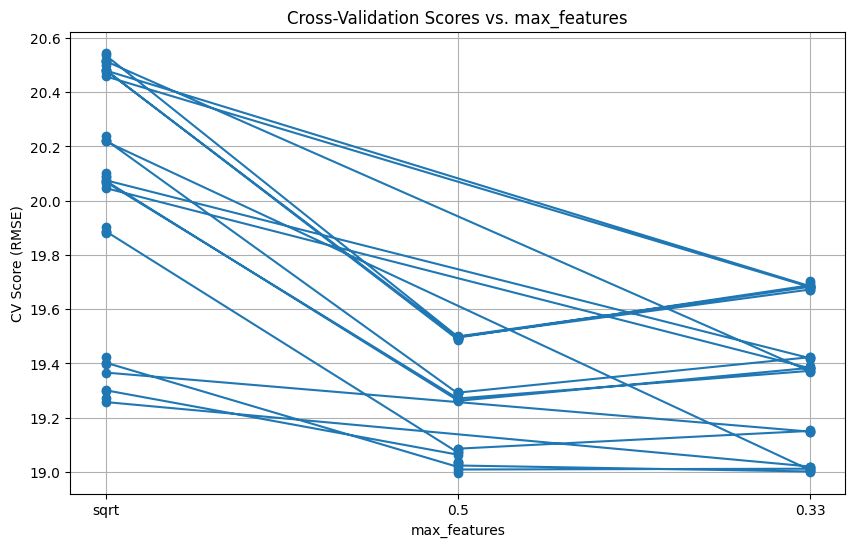

In [ ]:
# Extract relevant information from grid_search_rf2
cv_results = grid_search_rf2.cv_results_
max_features = [str(params['max_features']) for params in grid_search_rf2.cv_results_['params']] # Convert to string
cv_scores = -grid_search_rf2.cv_results_['mean_test_score'] # Negate as the scoring is neg_root_mean_squared_error

# Create a DataFrame for easier plotting
results_df = pd.DataFrame({'max_features': max_features, 'cv_score': cv_scores})

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(results_df['max_features'], results_df['cv_score'], marker='o')
plt.xlabel('max_features')
plt.ylabel('CV Score (RMSE)')
plt.title('Cross-Validation Scores vs. max_features')
plt.grid(True)
plt.show()

####Feature Importance

We have decided to use Random Forests to check our feature importances. We have found that the columns we added from the other datasets are among the most important, which explains why we see improved performance for our models across the board. The original columns were not as important, which support our findings from the data visulizations sectoin!

In [ ]:
# Get feature importances
importances = best_rf_regressor2.feature_importances_

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
feature_importances

,Feature,Importance
18,pct_pos_total,0.423239
26,Years old,0.064582
22,Detailed Description Rating (0–10),0.052836
2,Price,0.047622
23,Short Description Rating (0–10),0.046510
29,Number of Tags,0.045470
19,num_reviews_total,0.040753
10,Achievements,0.038493
24,Num games published by publisher,0.032241
25,Num games developed by developer,0.029779


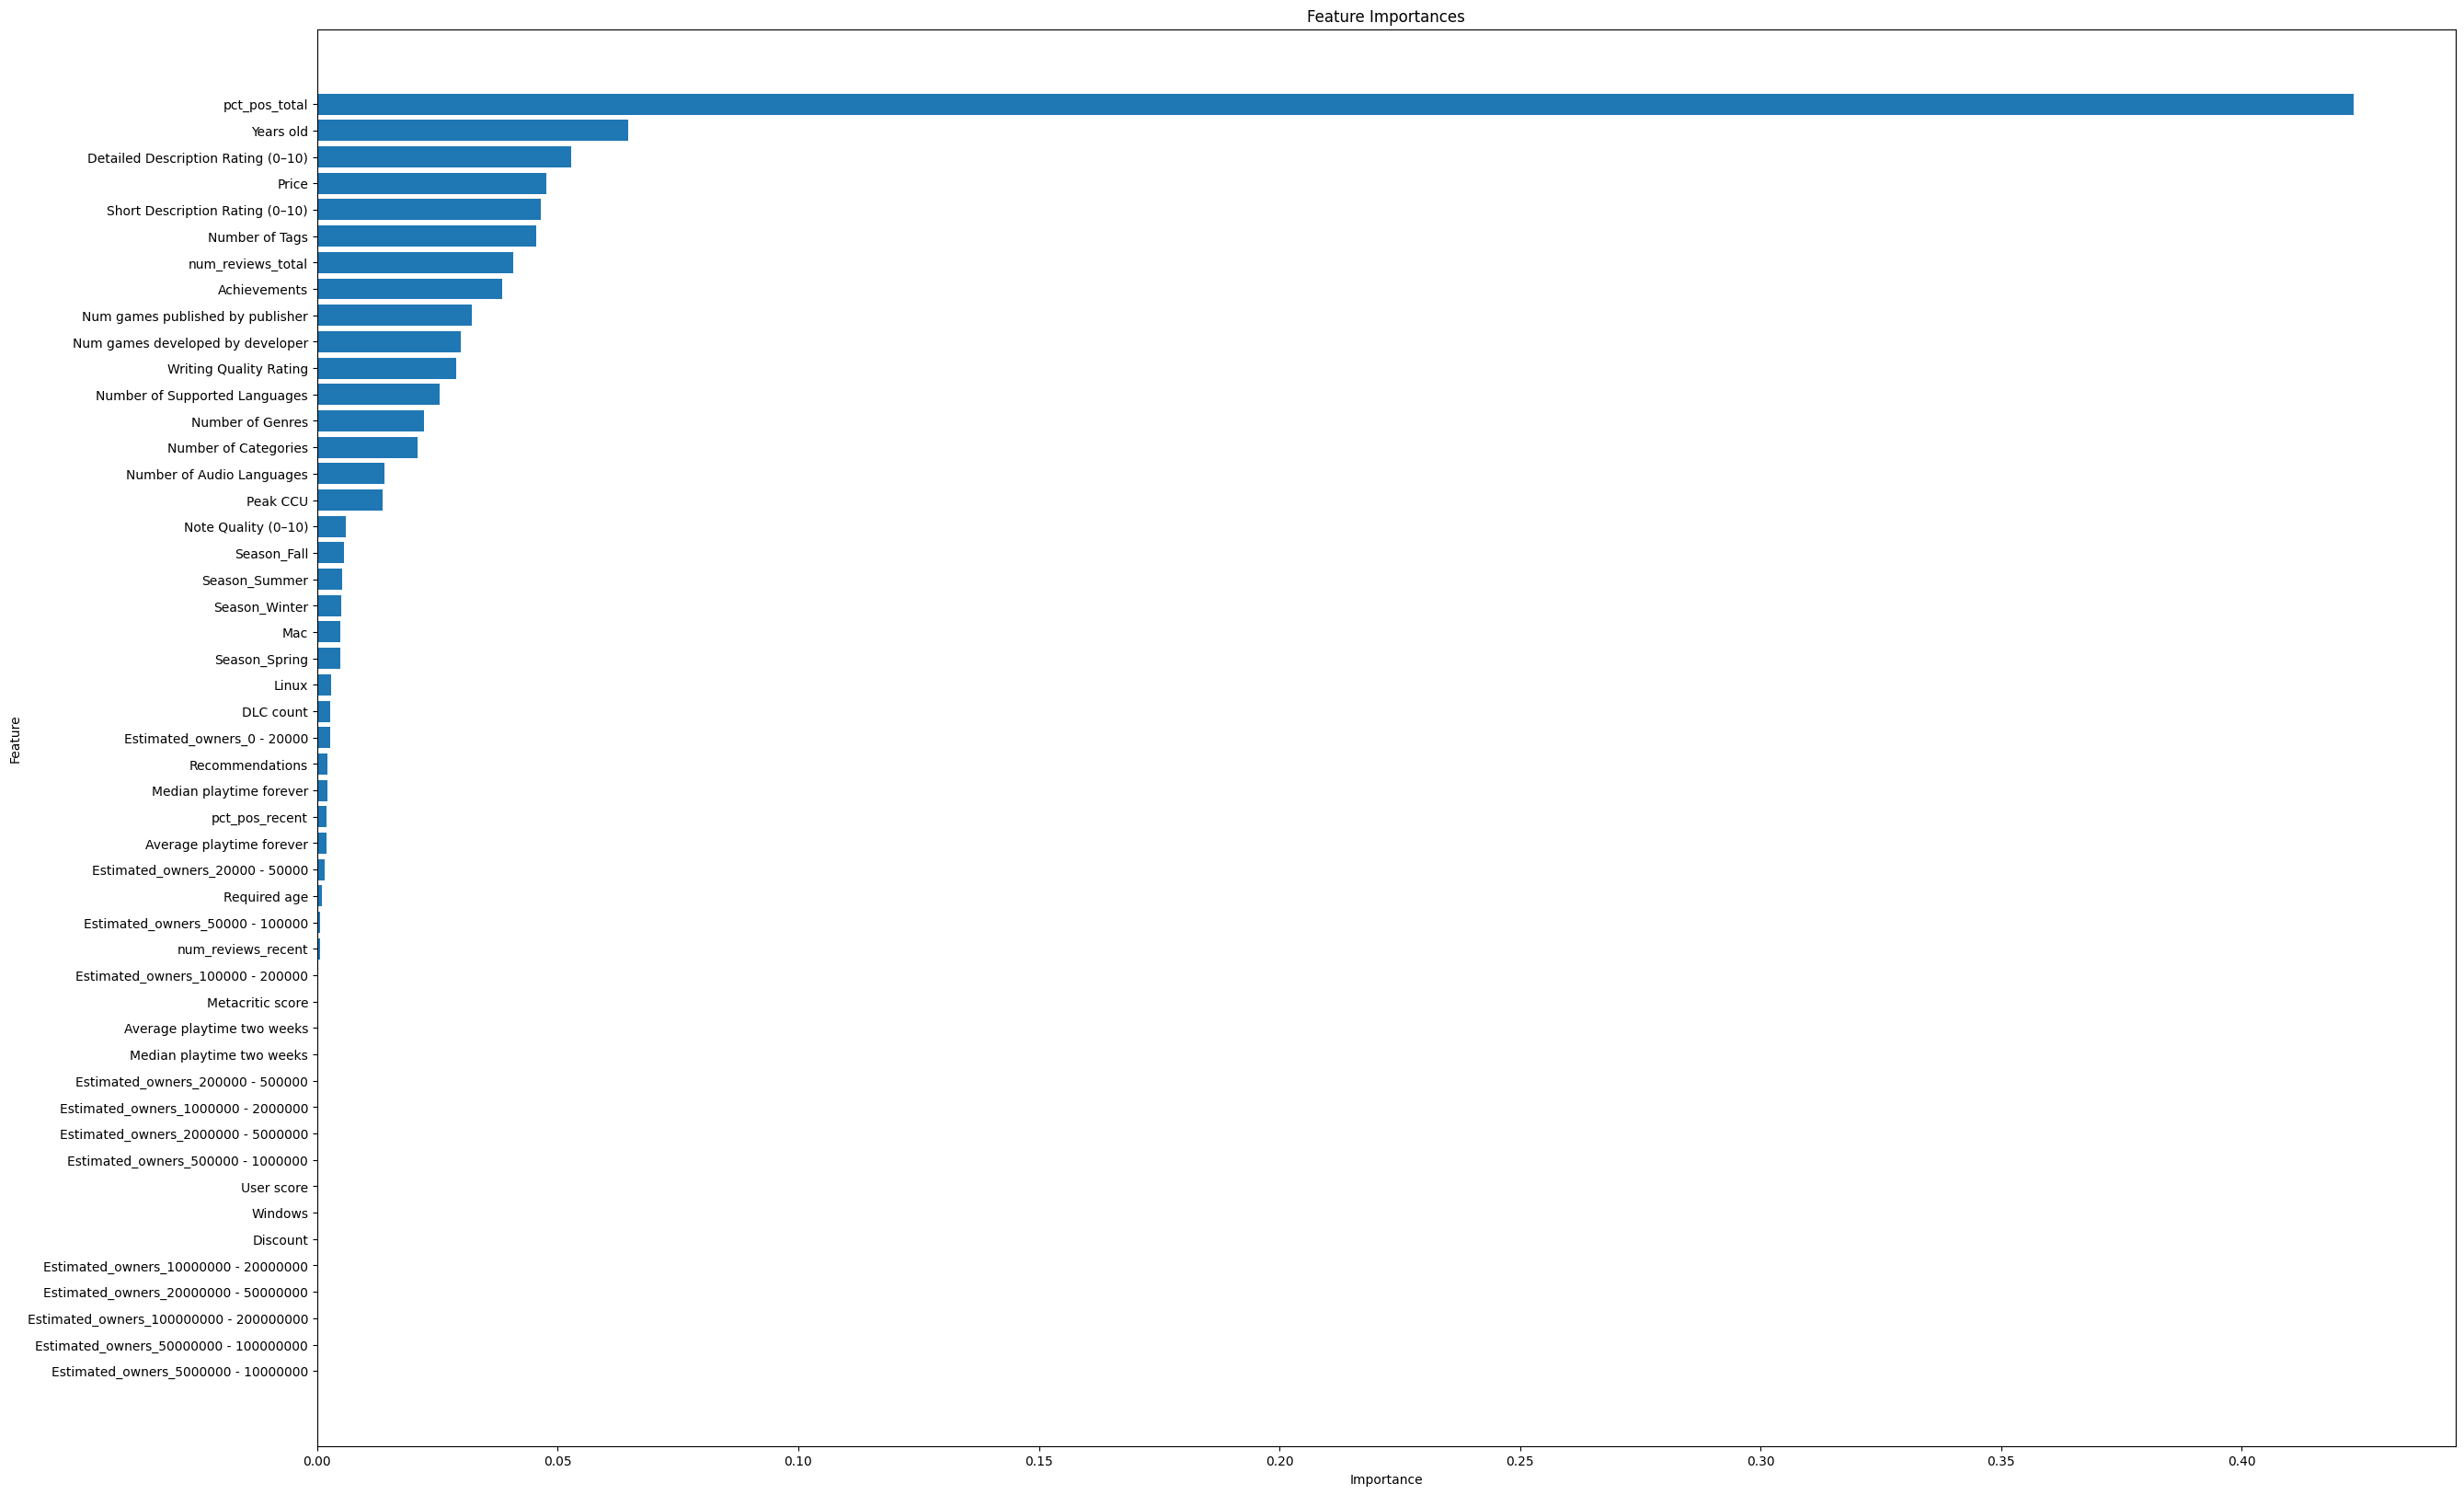

In [ ]:
plt.figure(figsize=(30, 20))
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importances")
plt.gca().invert_yaxis()  # Invert y-axis to display the most important features at the top
plt.show()

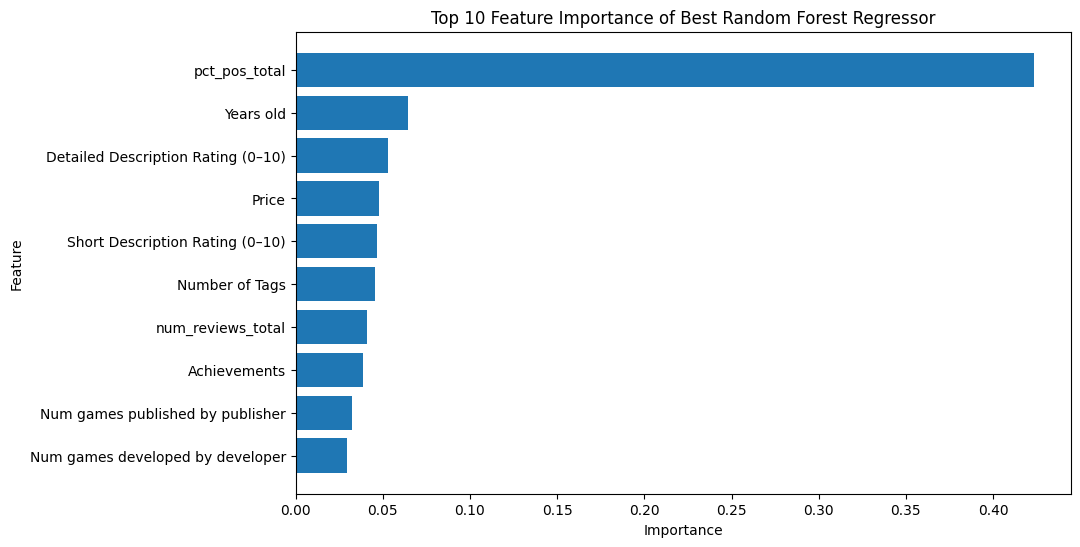

In [ ]:
feature_importances = best_rf_regressor2.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easier sorting
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Get the top 10 features
top_10_features = importances_df.head(10)

# Create the plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance of Best Random Forest Regressor')
plt.gca().invert_yaxis()  # Invert the y-axis
plt.show()

###Linear Regression

We also ran a simple linear regression(LR) model and found it performs on the worse side but this can be because LR assumes a linear relationship(which our dataset may not have).

In [ ]:
# Initialize and train the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate RMSE for the linear regression model
rmse_lr = math.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression RMSE (Scaled Data): {rmse_lr}")

Linear Regression RMSE (Scaled Data): 21.781660008789885


####Cross Validation

We decided to run a cross validation on Linear Regression so that we could more directly compare it with the other models.

In [ ]:
# Assuming X_train_scaled and y_train are defined from your previous code
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')

print("Cross-validation scores:", cv_scores)
print("Average CV score (RMSE):", -cv_scores.mean())


Cross-validation scores: [-21.73046513 -21.7412647  -22.01477357 -22.11944471 -21.98631175]
Average CV score (RMSE): 21.918451971066926


####Linear Regressoin Visualizatons

We created some visuals based on our linear regression model.

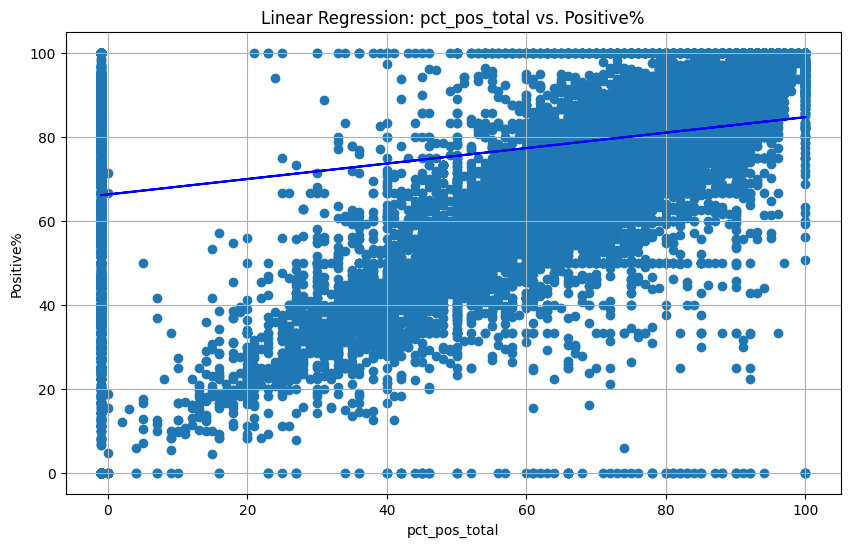

In [ ]:
# Extract the 'pct_pos_total' column and the target variable 'Positive%'
pct_pos_total = X_train['pct_pos_total']
positive_percentage = y_train

# Fit the linear regression model
lr_model = LinearRegression()
lr_model.fit(pct_pos_total.values.reshape(-1, 1), positive_percentage) # Reshape for single feature

# Make predictions
y_pred = lr_model.predict(pct_pos_total.values.reshape(-1, 1))

# Create the scatter plot with the regression line
plt.figure(figsize=(10, 6))
plt.scatter(pct_pos_total, positive_percentage, label='Actual Data')
plt.plot(pct_pos_total, y_pred, color='blue', label='Linear Regression Line')
plt.xlabel('pct_pos_total')
plt.ylabel('Positive%')
plt.title('Linear Regression: pct_pos_total vs. Positive%')
plt.grid(True)
plt.show()

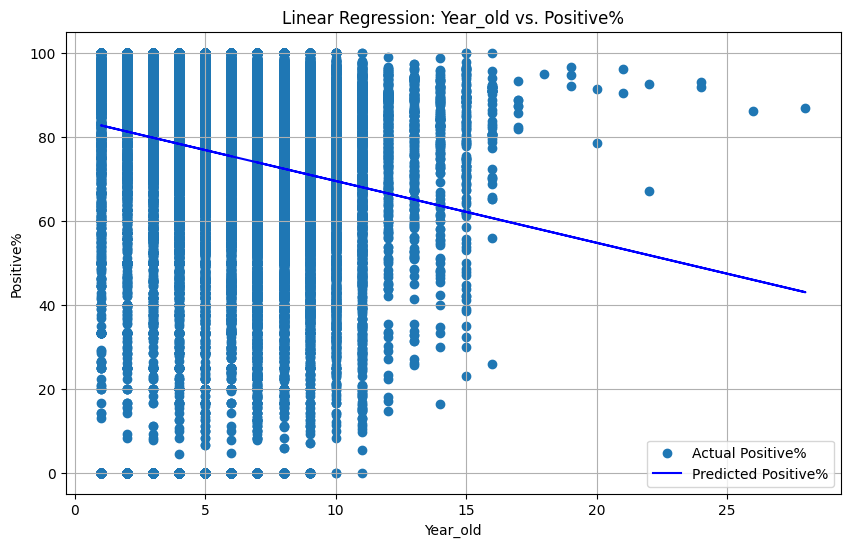

In [ ]:
# Extract 'Year_old' feature
year_old = X_train['Years old']

# Reshape year_old to have a single column for prediction
year_old_reshaped = year_old.values.reshape(-1, 1)

# Fit a new linear regression model using 'Year_old'
lr_model_year = LinearRegression()  # Create a new model
lr_model_year.fit(year_old_reshaped, y_train)

# Predict 'Positive%' using the new model
positive_percent_pred = lr_model_year.predict(year_old_reshaped)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(year_old, y_train, label='Actual Positive%')  # Actual values
plt.plot(year_old, positive_percent_pred, color='blue', label='Predicted Positive%')  # Predicted values
plt.xlabel('Year_old')
plt.ylabel('Positive%')
plt.title('Linear Regression: Year_old vs. Positive%')
plt.legend()
plt.grid(True)
plt.show()

###Nueral Network

Finally, we ran a Neural Network model, and found that it performed second best, being only beat out by Random Forests. As with the other models, we have ran hyperparameter tunning using Grid Search CV. We found that our first tuned model performed better, so we decided to go with that.   

####Base Neural Network Model

In [ ]:
# Initialize and train the MLPRegressor
mlp_regressor = MLPRegressor(hidden_layer_sizes=(10), max_iter=1000, activation='logistic',solver='lbfgs', random_state=1) # Adjust hidden_layer_sizes and other hyperparameters as needed
mlp_regressor.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_mlp = mlp_regressor.predict(X_test_scaled)

# Calculate RMSE for the MLPRegressor model
rmse_mlp = math.sqrt(mean_squared_error(y_test, y_pred_mlp))
print(f"MLPRegressor RMSE (Scaled Data): {rmse_mlp}")

MLPRegressor RMSE (Scaled Data): 19.122240850610584


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


In [ ]:
mlp_regressor = MLPRegressor(hidden_layer_sizes=(10), max_iter=1000, activation='logistic', solver='lbfgs', random_state=1)
cv_scores = cross_val_score(mlp_regressor, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')

print("Cross-validation scores:", cv_scores)
print("Average CV score (RMSE):", -cv_scores.mean())

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

Cross-validation scores: [-19.17992648 -19.04989629 -19.52963123 -19.92357644 -19.63879243]
Average CV score (RMSE): 19.464364572396562


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


####Tuned Neural Network Models

In [ ]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,),(50,50),(100,)],
    'activation': ['logistic'],
    'alpha': [0.05,1],
    'learning_rate': ['constant','adaptive']
}

mlp_regressor = MLPRegressor(random_state=1, max_iter=1000)
grid_search_mlp1 = GridSearchCV(estimator=mlp_regressor, param_grid=param_grid_mlp, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_mlp1.fit(X_train_scaled, y_train)

best_params_mlp1 = grid_search_mlp1.best_params_
best_mlp_regressor1 = grid_search_mlp1.best_estimator_
best_score_mlp1 = grid_search_mlp1.best_score_

print("Best hyperparameters:", best_params_mlp1)
print("Best cross-validation score (RMSE):", -best_score_mlp1)
print("Best cross-validation RMSE:", -best_score_mlp1)



y_pred_mlp = best_mlp_regressor1.predict(X_test_scaled)
rmse_mlp = math.sqrt(mean_squared_error(y_test, y_pred_mlp))
print(f"Tuned MLPRegressor RMSE (Scaled Data): {rmse_mlp}")

Best hyperparameters: {'activation': 'logistic', 'alpha': 1, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant'}
Best cross-validation score (RMSE): 19.443233812129034
Best cross-validation RMSE: 4.409448243502698
Tuned MLPRegressor RMSE (Scaled Data): 19.076672232159407


In [ ]:
param_grid_mlp = {
    'hidden_layer_sizes': [(100,100),(150,150),(200,200)],
    'activation': ['logistic','relu'],
    'alpha': [1,1.5],
    'learning_rate': ['constant','adaptive']
}

mlp_regressor2 = MLPRegressor(random_state=1, max_iter=1000)
grid_search_mlp = GridSearchCV(estimator=mlp_regressor2, param_grid=param_grid_mlp, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_mlp.fit(X_train_scaled, y_train)

best_params_mlp2 = grid_search_mlp.best_params_
best_mlp_regressor2 = grid_search_mlp.best_estimator_
best_score_mlp2 = grid_search_mlp.best_score_

print("Best hyperparameters:", best_params_mlp2)
print("Best cross-validation score (RMSE):", -best_score_mlp2)
print("Best cross-validation RMSE:", -best_score_mlp2)




y_pred_mlp = best_mlp_regressor2.predict(X_test_scaled)
rmse_mlp = math.sqrt(mean_squared_error(y_test, y_pred_mlp))
print(f"Tuned MLPRegressor RMSE (Scaled Data): {rmse_mlp}")

Best hyperparameters: {'activation': 'logistic', 'alpha': 1.5, 'hidden_layer_sizes': (150, 150), 'learning_rate': 'constant'}
Best cross-validation score (RMSE): 19.483884029736465
Best cross-validation RMSE: 19.483884029736465
Tuned MLPRegressor RMSE (Scaled Data): 19.055063387145644


####Neural Network Visuals

We visualized the hidden layer size(primarily to put in the presentation) and found that it supports what we found when tuning the model, that having one hidden layer with 100 neurons is most optimal.

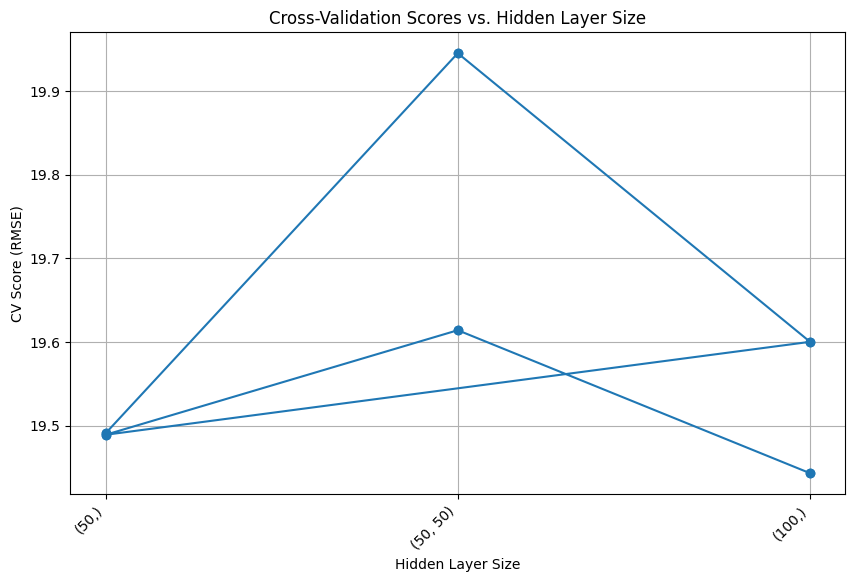

In [ ]:
#Define CV_results
cv_results = grid_search_mlp1.cv_results_

# Extract hidden layer sizes and their corresponding CV scores
hidden_layer_sizes = [str(params['hidden_layer_sizes']) for params in cv_results['params']]
cv_scores = -cv_results['mean_test_score']  # Negate as scoring is neg_root_mean_squared_error


# Create a DataFrame for easier plotting
results_df = pd.DataFrame({'Hidden Layer Size': hidden_layer_sizes, 'CV Score (RMSE)': cv_scores})

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(results_df['Hidden Layer Size'], results_df['CV Score (RMSE)'], marker='o')
plt.xlabel('Hidden Layer Size')
plt.ylabel('CV Score (RMSE)')
plt.title('Cross-Validation Scores vs. Hidden Layer Size')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(True)
plt.show()


##Conclusion

If we had to choose a model, it would be decision trees because the results are slightly worse than Neural Networks and Random Forests but the gain in interpretibility is worth it. This will help game developers more easily understand what combination of game features would yield to high positive%.


**However**, all of the results are not great because an RMSE of around 19 is still too high. Being off by this much means the model may give a way lower score to an overwhelmingly positive game and vice versa. As a result, game developers should prioritize features that are unique to each game's design to improve game reception.